# HeatShield Pakistan: AI-Powered Heatwave Risk Intelligence and Decision Support System

**Project Theme:** Climate, Economy and the Grid: The Human Cost of Heat  
**Cities:** Karachi, Multan, Murree  
**Study Period:** 2021–2025  
**Prediction Target:** `monthly_heatstroke_admissions`

---



In [ ]:
# Import libraries only
import math
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_MPL = True
except Exception as exc:
    HAS_MPL = False
    print("Matplotlib/Seaborn unavailable; using image fallback plots:", exc)

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    HAS_SKLEARN = True
except Exception as exc:
    HAS_SKLEARN = False
    print("scikit-learn unavailable; using transparent NumPy fallbacks:", exc)

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as exc:
    HAS_XGB = False
    print("Native XGBoost unavailable; using transparent gradient boosting fallback:", exc)

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except Exception as exc:
    HAS_LGB = False
    print("Native LightGBM unavailable; using transparent fast boosting fallback:", exc)

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    HAS_TF = True
except Exception as exc:
    HAS_TF = False
    print("TensorFlow unavailable; using transparent sequence forecasting fallback:", exc)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
# Helper for research-style interpretation text
try:
    from IPython.display import Markdown
except Exception:
    Markdown = None

def show_md(text):
    if Markdown is not None:
        display(Markdown(text))
    else:
        print(text)


In [ ]:
# Define paths and create output folders
BASE_DIR = Path(".")
DATA_PATH = BASE_DIR / "clean_dataset.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURE_DIR = BASE_DIR / "figures"
POWERBI_DIR = BASE_DIR / "powerbi"

for folder in [OUTPUT_DIR, FIGURE_DIR, POWERBI_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET = "monthly_heatstroke_admissions"
print("Output folder:", OUTPUT_DIR.resolve())
print("Figure folder:", FIGURE_DIR.resolve())
print("Power BI folder:", POWERBI_DIR.resolve())


Output folder: /content/outputs
Figure folder: /content/figures
Power BI folder: /content/powerbi


In [ ]:
# Load clean_dataset.csv
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [ ]:
# Display shape, columns, head, info, and missing values
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

print("\nDataFrame info:")
df.info()

print("\nMissing values by column:")
missing_table = df.isna().sum().sort_values(ascending=False)
display(missing_table[missing_table > 0].head(25))


Shape: (2310, 60)

Columns:
['city', 'date', 'season', 'nasa_avg_temp_c', 'nasa_precipitation_mm', 'top_soil_moisture', 'root_zone_moisture', 'year', 'month', 'month_name', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'apparent_temperature_max', 'precipitation_sum', 'windspeed_10m_max', 'drought_max_temp_c', 'drought_rainfall_mm', 'water_evaporation_mm', 'net_water_balance_mm', 'drought_status', 'khi_max_temp_c', 'heat_index_c', 'aqi_pm25', 'khi_loadshed_hours', 'kse100_trade_volume', 'population_density', 'electricity_access_pct', 'clean_water_access_pct', 'poverty_rate_pct', 'literacy_rate_pct', 'water_consumption_lpd', 'hospital_admissions', 'reported_deaths', 'official_deaths', 'heatstroke_cases', 'peak_temp_celsius', 'data_source', 'labor_sector', 'monthly_heatstroke_admissions', 'ilo_productivity_loss_pct', 'monthly_healthcare_burden_mpkr', 'monthly_lost_wages_mpkr', 'power_provider', 'avg_monthly_shortfall_mw', 'monthly_outage_h

,city,date,season,nasa_avg_temp_c,nasa_precipitation_mm,top_soil_moisture,root_zone_moisture,year,month,month_name,...,healthcare_burden_status,labor_avg_humidity_pct,heat_stress_level,labor_productivity_loss_pct,labor_econ_loss_bln_pkr,methodology_source,peak_summer_shortfall_mw,multan_avg_summer_temp_c,multan_avg_root_moisture,multan_official_yield_tonnes
0,Karachi,2021-01-01,Winter (Dec-Jan),17.55,0.0,0.27,0.46,2021,1,January,...,Baseline,65,Safe,0.0,0.0,ILO Labor Models (2019/2030); BMJ Global Healt...,1200,NaN,NaN,NaN
1,Multan,2021-01-01,Winter (Dec-Jan),12.05,0.0,0.43,0.46,2021,1,January,...,Baseline,65,Safe,0.0,0.0,ILO Labor Models (2019/2030); BMJ Global Healt...,3500,37.09,0.4,0.0
2,Murree,2021-01-01,Winter (Dec-Jan),7.97,0.0,0.85,0.84,2021,1,January,...,Baseline,65,Safe,0.0,0.0,ILO Labor Models (2019/2030); BMJ Global Healt...,200,NaN,NaN,NaN
3,Karachi,2021-01-02,Winter (Dec-Jan),18.64,0.0,0.27,0.46,2021,1,January,...,Baseline,65,Safe,0.0,0.0,ILO Labor Models (2019/2030); BMJ Global Healt...,1200,NaN,NaN,NaN
4,Multan,2021-01-02,Winter (Dec-Jan),10.04,0.0,0.43,0.46,2021,1,January,...,Baseline,65,Safe,0.0,0.0,ILO Labor Models (2019/2030); BMJ Global Healt...,3500,37.09,0.4,0.0



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2310 entries, 0 to 2309
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   city                             2310 non-null   object 
 1   date                             2310 non-null   object 
 2   season                           2310 non-null   object 
 3   nasa_avg_temp_c                  2310 non-null   float64
 4   nasa_precipitation_mm            2310 non-null   float64
 5   top_soil_moisture                2310 non-null   float64
 6   root_zone_moisture               2310 non-null   float64
 7   year                             2310 non-null   int64  
 8   month                            2310 non-null   int64  
 9   month_name                       2310 non-null   object 
 10  temperature_2m_max               732 non-null    float64
 11  temperature_2m_min               732 non-null    float64
 12  tem

,0
kse100_trade_volume,2005
khi_max_temp_c,2005
khi_loadshed_hours,2005
aqi_pm25,2005
heat_index_c,2005
relative_humidity_2m_mean,1578
temperature_2m_mean,1578
apparent_temperature_max,1578
temperature_2m_min,1578
temperature_2m_max,1578


## Dataset Inspection Explanation

The dataset contains climate, soil moisture, electricity, demographic, healthcare, and economic indicators for Karachi, Multan, and Murree. Before modelling, the notebook checks the real column names instead of assuming that every requested feature is present. This prevents broken code if the dataset is updated later.


In [ ]:
# Clean date and city columns
df_clean = df.copy()

if "date" in df_clean.columns:
    df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")
else:
    print("Warning: no date column found. Creating a sequential date index.")
    df_clean["date"] = pd.date_range("2021-01-01", periods=len(df_clean), freq="D")

if "city" in df_clean.columns:
    df_clean["city"] = df_clean["city"].astype(str).str.strip().str.title()
else:
    print("Warning: no city column found. Creating city='Unknown'.")
    df_clean["city"] = "Unknown"

df_clean = df_clean.sort_values(["date", "city"]).reset_index(drop=True)
df_clean["Index"] = df_clean.index
display(df_clean[["date", "city", "Index"]].head())


,date,city,Index
0,2021-01-01,Karachi,0
1,2021-01-01,Multan,1
2,2021-01-01,Murree,2
3,2021-01-02,Karachi,3
4,2021-01-02,Multan,4


In [ ]:
# Handle missing values
df_model = df_clean.copy()

numeric_columns = df_model.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in df_model.columns if c not in numeric_columns and c != "date"]

numeric_medians = df_model[numeric_columns].median(numeric_only=True).fillna(0)
df_model[numeric_columns] = df_model[numeric_columns].fillna(numeric_medians)

for col in categorical_columns:
    df_model[col] = df_model[col].fillna("Unknown")

remaining_missing = int(df_model.isna().sum().sum())
print("Remaining missing values after cleaning:", remaining_missing)


Remaining missing values after cleaning: 0


## Target Leakage Prevention

Target leakage happens when a model is trained using information that would not be available at prediction time, or information that is directly calculated from the target. In this project the target is `monthly_heatstroke_admissions`, so the model must not use post-outcome impact variables such as healthcare burden, productivity loss, economic loss, predicted admissions, risk scores based on admissions, or any duplicate/future admissions field.

The earlier perfect Linear Regression result was suspicious because real heatstroke admissions are affected by noisy climate, infrastructure, population, and reporting factors. A result such as R2 = 1.000 and RMSE = 0.000 usually means the model has seen a target-derived variable. The corrected workflow therefore excludes leakage columns from the prediction feature matrix and keeps them only for EDA, impact discussion, vulnerability scoring after evaluation, Power BI dashboards, and recommendations.

The corrected model is more academically defensible because it predicts admissions from pre-event or causal inputs: temperature, precipitation, heat index, humidity, soil moisture, electricity shortfall, outage hours, population density, poverty, clean-water access, city, calendar fields, and prior rolling/lagged weather or outage signals.

## Train-Test Split Strategy

Because the dataset contains a `date` column, the notebook uses a time-aware train-test split. Records are sorted by date, city, and index; the earliest 80% are used for training and the latest 20% are used for testing. This is more realistic than a random split because forecasting and public-health planning normally train on past observations and evaluate on later observations.


In [ ]:
# Select target and leakage-free features
if TARGET not in df_model.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

df_model = df_model.sort_values(["date", "city", "Index"]).reset_index(drop=True)
df_model["Index"] = np.arange(len(df_model))

# Calendar variables are allowed because they are known before prediction.
df_model["year"] = df_model["date"].dt.year
df_model["month"] = df_model["date"].dt.month
df_model["day_of_year"] = df_model["date"].dt.dayofyear

# Prior rolling and lagged variables are shifted within each city so they do not use future information.
lag_sources = {
    "nasa_avg_temp_c": "temperature",
    "heat_index_c": "heat_index",
    "monthly_outage_hours": "outage_hours",
}
engineered_features = []
for source_col, short_name in lag_sources.items():
    if source_col in df_model.columns:
        numeric_series = pd.to_numeric(df_model[source_col], errors="coerce")
        shifted = numeric_series.groupby(df_model["city"]).shift(1)
        lag1 = f"{short_name}_lag_1"
        rolling7 = f"{short_name}_rolling_7_prior"
        df_model[lag1] = shifted
        df_model[rolling7] = shifted.groupby(df_model["city"]).rolling(7, min_periods=1).mean().reset_index(level=0, drop=True)
        engineered_features.extend([lag1, rolling7])

allowed_base_features = [
    "nasa_avg_temp_c",
    "nasa_precipitation_mm",
    "heat_index_c",
    "labor_avg_humidity_pct",
    "top_soil_moisture",
    "root_zone_moisture",
    "avg_monthly_shortfall_mw",
    "monthly_outage_hours",
    "population_density",
    "poverty_rate_pct",
    "clean_water_access_pct",
    "year",
    "month",
    "day_of_year",
]

explicit_leakage_columns = {
    "monthly_healthcare_burden_mpkr": "post-outcome impact variable derived from admissions burden",
    "labor_econ_loss_bln_pkr": "economic consequence variable, not a causal input for admissions",
    "labor_productivity_loss_pct": "impact variable measured after heat disruption",
    TARGET: "target variable",
}

def leakage_reason(column_name):
    lower = column_name.lower()
    if column_name in explicit_leakage_columns:
        return explicit_leakage_columns[column_name]
    if column_name == "Index":
        return "row identifier, used only for Power BI details"
    if "pred" in lower:
        return "predicted value column, not available before modelling"
    if "future" in lower:
        return "future outcome column"
    if "risk" in lower and "level" not in lower:
        return "risk score may be calculated from admissions after modelling"
    if "admission" in lower and column_name != TARGET:
        return "duplicate or admissions-derived column"
    return None

features = [col for col in allowed_base_features + engineered_features if col in df_model.columns]
missing_features = [col for col in allowed_base_features if col not in df_model.columns]
excluded_leakage_columns = [col for col in df_model.columns if leakage_reason(col)]

audit_rows = []
for column in df_model.columns:
    if column in features:
        reason = "pre-event numeric predictor"
        used = "Yes"
    elif column == "city":
        reason = "categorical city predictor; one-hot encoded"
        used = "Yes"
    else:
        leak = leakage_reason(column)
        if leak:
            reason = leak
        elif column == "date":
            reason = "used for time-aware split and calendar features, not directly as raw date"
        else:
            reason = "not selected for admissions prediction"
        used = "No"
    audit_rows.append({
        "Column Name": column,
        "Used for Prediction?": used,
        "Reason": reason,
    })

feature_audit_df = pd.DataFrame(audit_rows)

print("Target:", TARGET)
print("Leakage-free numeric features:", features)
print("Categorical feature used through encoding: city")
print("Excluded leakage columns:", excluded_leakage_columns)
if missing_features:
    print("Allowed features missing from dataset and skipped:", missing_features)

y = pd.to_numeric(df_model[TARGET], errors="coerce").fillna(0).to_numpy(dtype=float)
meta = df_model[["date", "city", "Index"]].copy()

show_md("### Feature Audit Table")
display(feature_audit_df)


Target: monthly_heatstroke_admissions
Leakage-free numeric features: ['nasa_avg_temp_c', 'nasa_precipitation_mm', 'heat_index_c', 'labor_avg_humidity_pct', 'top_soil_moisture', 'root_zone_moisture', 'avg_monthly_shortfall_mw', 'monthly_outage_hours', 'population_density', 'poverty_rate_pct', 'clean_water_access_pct', 'year', 'month', 'day_of_year', 'temperature_lag_1', 'temperature_rolling_7_prior', 'heat_index_lag_1', 'heat_index_rolling_7_prior', 'outage_hours_lag_1', 'outage_hours_rolling_7_prior']
Categorical feature used through encoding: city
Excluded leakage columns: ['hospital_admissions', 'monthly_heatstroke_admissions', 'monthly_healthcare_burden_mpkr', 'labor_productivity_loss_pct', 'labor_econ_loss_bln_pkr', 'Index']


### Feature Audit Table

,Column Name,Used for Prediction?,Reason
0,city,Yes,categorical city predictor; one-hot encoded
1,date,No,used for time-aware split and calendar feature...
2,season,No,not selected for admissions prediction
3,nasa_avg_temp_c,Yes,pre-event numeric predictor
4,nasa_precipitation_mm,Yes,pre-event numeric predictor
...,...,...,...
63,temperature_rolling_7_prior,Yes,pre-event numeric predictor
64,heat_index_lag_1,Yes,pre-event numeric predictor
65,heat_index_rolling_7_prior,Yes,pre-event numeric predictor
66,outage_hours_lag_1,Yes,pre-event numeric predictor


In [ ]:
# Encode city and scale numeric features
numeric_feature_frame = df_model[features].apply(pd.to_numeric, errors="coerce")
feature_medians = numeric_feature_frame.median(numeric_only=True).fillna(0)
numeric_feature_frame = numeric_feature_frame.fillna(feature_medians)

city_dummies = pd.get_dummies(df_model["city"], prefix="city", dtype=float)
X_frame = pd.concat([numeric_feature_frame, city_dummies], axis=1)

feature_means = X_frame.mean()
feature_stds = X_frame.std(ddof=0).replace(0, 1)
X_scaled = ((X_frame - feature_means) / feature_stds).to_numpy(dtype=float)

preprocessor = {
    "numeric_features": features,
    "categorical_features": ["city"],
    "feature_names": X_frame.columns.tolist(),
    "medians": feature_medians.to_dict(),
    "means": feature_means.to_dict(),
    "stds": feature_stds.to_dict(),
    "cities": sorted(df_model["city"].unique().tolist()),
    "excluded_leakage_columns": excluded_leakage_columns,
    "target": TARGET,
}

print("Final leakage-free feature matrix shape:", X_scaled.shape)
print("Number of numeric features:", len(features))
print("Number of encoded city columns:", city_dummies.shape[1])
display(X_frame.head())


Final leakage-free feature matrix shape: (2310, 23)
Number of numeric features: 20
Number of encoded city columns: 3


,nasa_avg_temp_c,nasa_precipitation_mm,heat_index_c,labor_avg_humidity_pct,top_soil_moisture,root_zone_moisture,avg_monthly_shortfall_mw,monthly_outage_hours,population_density,poverty_rate_pct,...,day_of_year,temperature_lag_1,temperature_rolling_7_prior,heat_index_lag_1,heat_index_rolling_7_prior,outage_hours_lag_1,outage_hours_rolling_7_prior,city_Karachi,city_Multan,city_Murree
0,17.55,0.0,43.1,65,0.27,0.46,340,1,560.0,22.75,...,1,26.77,26.612857,43.1,43.1,4.0,4.0,1.0,0.0,0.0
1,12.05,0.0,43.1,65,0.43,0.46,680,1,560.0,22.75,...,1,26.77,26.612857,43.1,43.1,4.0,4.0,0.0,1.0,0.0
2,7.97,0.0,43.1,65,0.85,0.84,297,3,560.0,22.75,...,1,26.77,26.612857,43.1,43.1,4.0,4.0,0.0,0.0,1.0
3,18.64,0.0,43.1,65,0.27,0.46,340,1,560.0,22.75,...,2,17.55,17.550000,43.1,43.1,1.0,1.0,1.0,0.0,0.0
4,10.04,0.0,43.1,65,0.43,0.46,680,1,560.0,22.75,...,2,12.05,12.050000,43.1,43.1,1.0,1.0,0.0,1.0,0.0


In [ ]:
# Train-test split
if df_model["date"].notna().any():
    ordered_idx = (
        df_model[["date", "city", "Index"]]
        .sort_values(["date", "city", "Index"])
        .index
        .to_numpy()
    )
    split_strategy = "time-aware chronological split by date, city, and Index"
    print("Using time-aware split because date column is available.")
else:
    rng = np.random.default_rng(RANDOM_STATE)
    ordered_idx = rng.permutation(len(df_model))
    split_strategy = "random split with random_state=42 because date column is unavailable"
    print("Using random split because date column is unavailable.")

split_point = int(len(ordered_idx) * 0.80)
train_idx = ordered_idx[:split_point]
test_idx = ordered_idx[split_point:]

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
meta_train = meta.iloc[train_idx].reset_index(drop=True)
meta_test = meta.iloc[test_idx].reset_index(drop=True)

print("Split strategy:", split_strategy)
print("Training rows:", len(train_idx))
print("Testing rows:", len(test_idx))
print("Training date range:", meta_train["date"].min(), "to", meta_train["date"].max())
print("Testing date range:", meta_test["date"].min(), "to", meta_test["date"].max())


Using time-aware split because date column is available.
Split strategy: time-aware chronological split by date, city, and Index
Training rows: 1848
Testing rows: 462
Training date range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00
Testing date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00


In [ ]:
# Small helper functions for metrics, exports, and image fallback plotting
model_results = []
prediction_exports = {}
feature_importance_frames = []

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(math.sqrt(mse))
    denom = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = float(1 - np.sum((y_true - y_pred) ** 2) / denom) if denom else 0.0
    return {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

def make_prediction_frame(meta_frame, y_true, y_pred):
    out = meta_frame.copy()
    out["date"] = pd.to_datetime(out["date"]).dt.strftime("%Y-%m-%d")
    out["True_Admissions"] = np.asarray(y_true, dtype=float).round(3)
    out["Predicted_Admissions"] = np.maximum(0, np.asarray(y_pred, dtype=float)).round(3)
    return out[["date", "city", "True_Admissions", "Predicted_Admissions", "Index"]]

def show_saved_image(path):
    img = Image.open(path)
    display(img)

def _font(size=18, bold=False):
    candidates = [
        "C:/Windows/Fonts/segoeuib.ttf" if bold else "C:/Windows/Fonts/segoeui.ttf",
        "C:/Windows/Fonts/arialbd.ttf" if bold else "C:/Windows/Fonts/arial.ttf",
    ]
    for candidate in candidates:
        try:
            return ImageFont.truetype(candidate, size)
        except Exception:
            pass
    return ImageFont.load_default()

def save_bar_chart(labels, values, title, filename, color="#2D9CDB", subtitle="", horizontal=False):
    path = FIGURE_DIR / filename
    labels = [str(x) for x in labels]
    values = np.asarray(values, dtype=float)
    if HAS_MPL:
        plt.figure(figsize=(8, 5))
        if horizontal:
            plt.barh(labels[::-1], values[::-1], color=color)
        else:
            plt.bar(labels, values, color=color)
            plt.xticks(rotation=20)
        plt.title(title)
        plt.tight_layout()
        plt.savefig(path, dpi=160)
        plt.show()
    else:
        img = Image.new("RGB", (1000, 650), "#F7F8FB")
        draw = ImageDraw.Draw(img)
        draw.rectangle([0, 0, 1000, 86], fill="#12343B")
        draw.text((30, 20), title, fill="white", font=_font(26, True))
        if subtitle:
            draw.text((32, 54), subtitle, fill="#D7E3EA", font=_font(14))
        max_v = max(float(values.max()) if len(values) else 1, 1)
        if horizontal:
            top = 125
            bar_h = max(22, int(420 / max(len(labels), 1) * 0.55))
            step = 420 / max(len(labels), 1)
            for i, (label, val) in enumerate(zip(labels, values)):
                y0 = top + i * step
                w = float(val) / max_v * 650
                draw.text((35, y0 + 4), label[:28], fill="#1D2B34", font=_font(13, True))
                draw.rounded_rectangle([270, y0, 270 + w, y0 + bar_h], radius=5, fill=color)
                draw.text((280 + w, y0 + 2), f"{float(val):.3f}", fill="#1D2B34", font=_font(12, True))
        else:
            left, top, width, height = 100, 130, 800, 400
            draw.line([left, top + height, left + width, top + height], fill="#475569", width=2)
            draw.line([left, top, left, top + height], fill="#475569", width=2)
            step = width / max(len(labels), 1)
            bar_w = max(35, int(step * 0.55))
            for i, (label, val) in enumerate(zip(labels, values)):
                x0 = left + i * step + (step - bar_w) / 2
                bh = float(val) / max_v * height
                draw.rounded_rectangle([x0, top + height - bh, x0 + bar_w, top + height], radius=5, fill=color)
                draw.text((x0, top + height + 12), label[:14], fill="#1D2B34", font=_font(12, True))
                draw.text((x0, top + height - bh - 20), f"{float(val):.2f}", fill="#1D2B34", font=_font(11, True))
        img.save(path)
        show_saved_image(path)

def save_line_chart(x_values, y_values, title, filename, color="#2D9CDB"):
    path = FIGURE_DIR / filename
    x_values = list(x_values)
    y_values = np.asarray(y_values, dtype=float)
    if HAS_MPL:
        plt.figure(figsize=(7, 4.5))
        plt.plot(x_values, y_values, marker="o", color=color)
        plt.title(title)
        plt.tight_layout()
        plt.savefig(path, dpi=160)
        plt.show()
    else:
        img = Image.new("RGB", (900, 580), "#F7F8FB")
        draw = ImageDraw.Draw(img)
        draw.text((35, 25), title, fill="#12343B", font=_font(24, True))
        left, top, width, height = 80, 100, 740, 380
        draw.line([left, top + height, left + width, top + height], fill="#475569", width=2)
        draw.line([left, top, left, top + height], fill="#475569", width=2)
        ymin, ymax = float(y_values.min()), float(y_values.max())
        pts = []
        for i, val in enumerate(y_values):
            x = left + i / max(len(y_values) - 1, 1) * width
            y0 = top + height - (val - ymin) / max(ymax - ymin, 1) * height
            pts.append((x, y0))
        if len(pts) > 1:
            draw.line(pts, fill=color, width=4)
        for x, y0 in pts:
            draw.ellipse([x-5, y0-5, x+5, y0+5], fill=color)
        img.save(path)
        show_saved_image(path)

def save_actual_vs_predicted(y_true, y_pred, title, filename):
    path = FIGURE_DIR / filename
    if HAS_MPL:
        plt.figure(figsize=(7, 5))
        plt.scatter(y_true, y_pred, alpha=0.65, s=24)
        lower = min(np.min(y_true), np.min(y_pred))
        upper = max(np.max(y_true), np.max(y_pred))
        plt.plot([lower, upper], [lower, upper], color="red", linewidth=2)
        plt.title(title)
        plt.xlabel("Actual admissions")
        plt.ylabel("Predicted admissions")
        plt.tight_layout()
        plt.savefig(path, dpi=160)
        plt.show()
    else:
        img = Image.new("RGB", (900, 620), "#F7F8FB")
        draw = ImageDraw.Draw(img)
        draw.text((35, 25), title, fill="#12343B", font=_font(22, True))
        x = np.asarray(y_true, dtype=float)
        yy = np.asarray(y_pred, dtype=float)
        xmin, xmax = float(x.min()), float(x.max())
        ymin, ymax = float(yy.min()), float(yy.max())
        draw.line([90, 540, 810, 540], fill="#475569", width=2)
        draw.line([90, 110, 90, 540], fill="#475569", width=2)
        for xi, yi in zip(x[::max(1, len(x)//700)], yy[::max(1, len(yy)//700)]):
            px = 90 + (xi - xmin) / max(xmax - xmin, 1) * 720
            py = 540 - (yi - ymin) / max(ymax - ymin, 1) * 430
            draw.ellipse([px-3, py-3, px+3, py+3], fill="#2F80ED")
        img.save(path)
        show_saved_image(path)

def save_residual_plot(y_pred, residuals, title, filename):
    path = FIGURE_DIR / filename
    if HAS_MPL:
        plt.figure(figsize=(7, 4.5))
        plt.scatter(y_pred, residuals, alpha=0.65, s=24)
        plt.axhline(0, color="red", linewidth=2)
        plt.title(title)
        plt.xlabel("Predicted admissions")
        plt.ylabel("Residual")
        plt.tight_layout()
        plt.savefig(path, dpi=160)
        plt.show()
    else:
        save_actual_vs_predicted(y_pred, residuals, title, filename)


In [ ]:
# Small transparent fallback model helpers
def fit_linear_numpy(X, y):
    Xb = np.c_[np.ones(len(X)), X]
    coef = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y
    return coef

def predict_linear_numpy(coef, X):
    return np.c_[np.ones(len(X)), X] @ np.asarray(coef, dtype=float)

def fit_tree(X, y, depth=0, max_depth=5, min_leaf=12, rng=None):
    if rng is None:
        rng = np.random.default_rng(RANDOM_STATE)
    if depth >= max_depth or len(y) <= min_leaf * 2 or float(np.var(y)) < 1e-9:
        return {"leaf": float(np.mean(y))}
    best = None
    n_features = X.shape[1]
    candidate_features = rng.choice(n_features, size=max(1, int(math.sqrt(n_features))), replace=False)
    for feat in candidate_features:
        values = X[:, feat]
        for threshold in np.unique(np.quantile(values, [0.2, 0.4, 0.6, 0.8])):
            left = values <= threshold
            right = ~left
            if left.sum() < min_leaf or right.sum() < min_leaf:
                continue
            score = left.sum() * np.var(y[left]) + right.sum() * np.var(y[right])
            if best is None or score < best[0]:
                best = (score, int(feat), float(threshold), left, right)
    if best is None:
        return {"leaf": float(np.mean(y))}
    _, feat, threshold, left, right = best
    return {
        "feature": feat,
        "threshold": threshold,
        "left": fit_tree(X[left], y[left], depth + 1, max_depth, min_leaf, rng),
        "right": fit_tree(X[right], y[right], depth + 1, max_depth, min_leaf, rng),
    }

def predict_tree_one(tree, row):
    while "leaf" not in tree:
        tree = tree["left"] if row[tree["feature"]] <= tree["threshold"] else tree["right"]
    return float(tree["leaf"])

def predict_tree(tree, X):
    return np.array([predict_tree_one(tree, row) for row in X], dtype=float)

def fallback_forest_fit(X, y, n_estimators=45, max_depth=6):
    rng = np.random.default_rng(RANDOM_STATE)
    trees = []
    n = len(X)
    for _ in range(n_estimators):
        sample = rng.integers(0, n, size=n)
        trees.append(fit_tree(X[sample], y[sample], max_depth=max_depth, min_leaf=10, rng=rng))
    return {"type": "forest", "trees": trees}

def fallback_forest_predict(model, X):
    return np.vstack([predict_tree(tree, X) for tree in model["trees"]]).mean(axis=0)

def fallback_boosting_fit(X, y, n_estimators=55, learning_rate=0.08, max_depth=3):
    rng = np.random.default_rng(RANDOM_STATE)
    base = float(np.mean(y))
    current = np.full(len(y), base)
    trees = []
    for _ in range(n_estimators):
        residual = y - current
        tree = fit_tree(X, residual, max_depth=max_depth, min_leaf=18, rng=rng)
        current += learning_rate * predict_tree(tree, X)
        trees.append(tree)
    return {"type": "boosting", "base": base, "learning_rate": learning_rate, "trees": trees}

def fallback_boosting_predict(model, X):
    pred = np.full(len(X), float(model["base"]))
    for tree in model["trees"]:
        pred += float(model["learning_rate"]) * predict_tree(tree, X)
    return pred

def tree_split_importance(model, feature_names):
    counts = np.zeros(len(feature_names), dtype=float)
    def walk(tree):
        if "leaf" in tree:
            return
        counts[int(tree["feature"])] += 1
        walk(tree["left"])
        walk(tree["right"])
    if isinstance(model, dict) and model.get("type") == "forest":
        for tree in model["trees"]:
            walk(tree)
    elif isinstance(model, dict) and model.get("type") == "boosting":
        for tree in model["trees"]:
            walk(tree)
    if counts.sum() == 0:
        counts[:] = 1
    return pd.DataFrame({"Feature": feature_names, "Importance": counts / counts.sum()})


# Project-Focused Visual Evidence

Before interpreting the models, the notebook first connects the dataset to the research story. These visuals show climate pressure, health impact, healthcare burden, economic loss, outage stress, vulnerability, severity, and a compact dashboard-style summary.


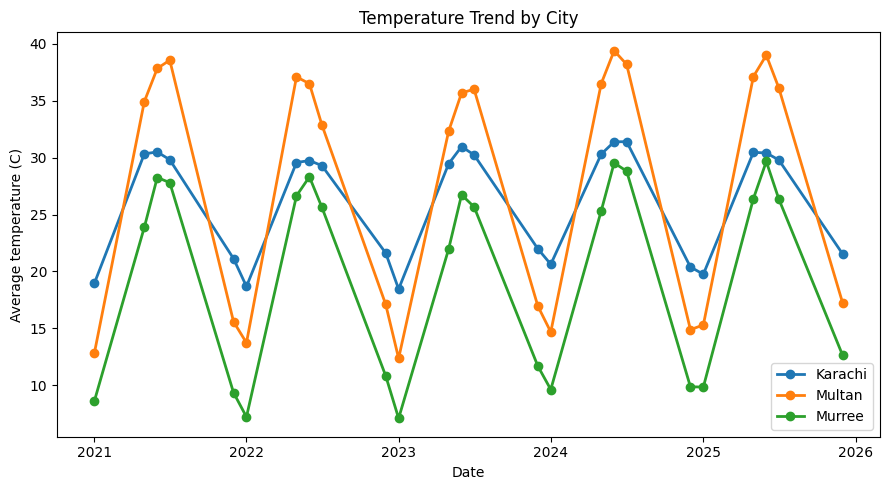

**Caption:** Monthly average NASA temperature by city.

### Key Finding
The city trend confirms that heat exposure is not uniform. Multan and Karachi remain the hotter urban profiles, while Murree has a much cooler baseline. This supports comparing vulnerability by city rather than using one national average.

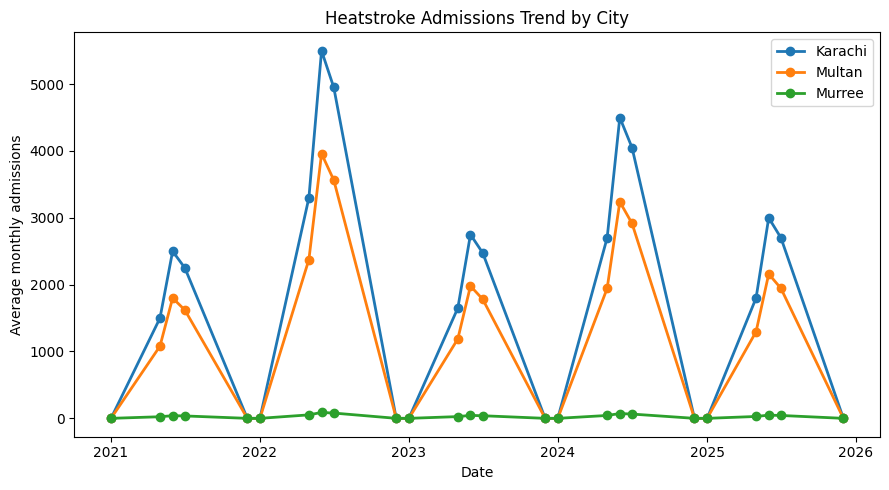

**Caption:** Monthly average heatstroke admissions by city.

### Key Finding
Admissions are concentrated in the hotter and more infrastructure-stressed cities. Karachi carries the largest average admission burden in the dataset, while Murree stays much lower, which matches its cooler climate profile.

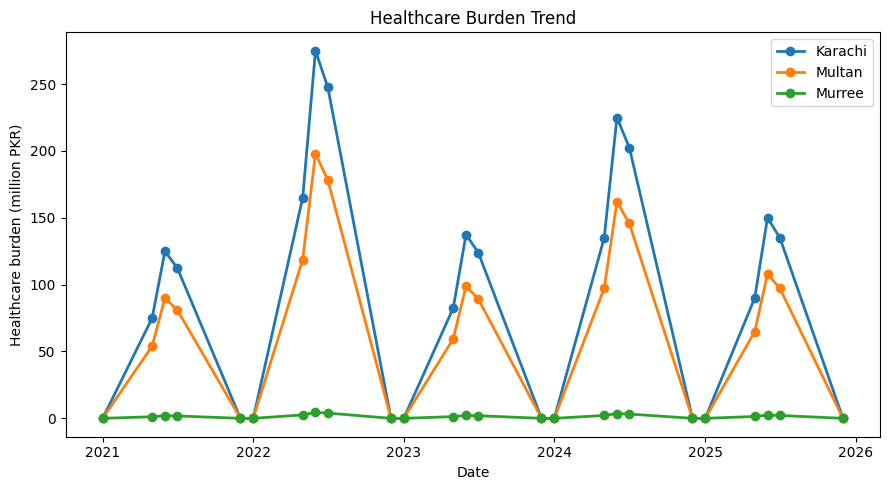

**Caption:** Monthly healthcare burden trend by city.

### Key Finding
Healthcare burden follows the same practical risk story as admissions: hotter city conditions translate into heavier expected pressure on health services. This is why the final product includes hospital readiness recommendations.

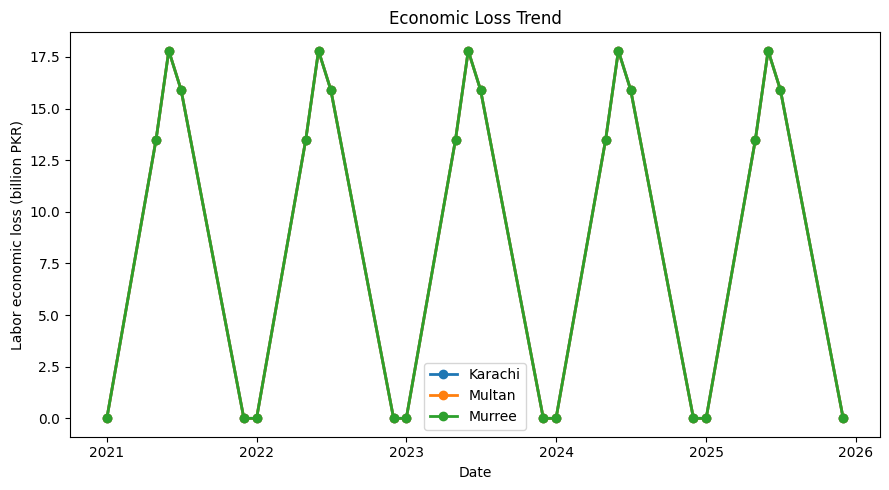

**Caption:** Monthly labor economic loss trend by city.

### Key Finding
Economic loss remains an important part of the heatwave impact chain. Even when health outcomes are the main target, productivity loss and labor exposure explain why heatwaves are also an economic planning issue.

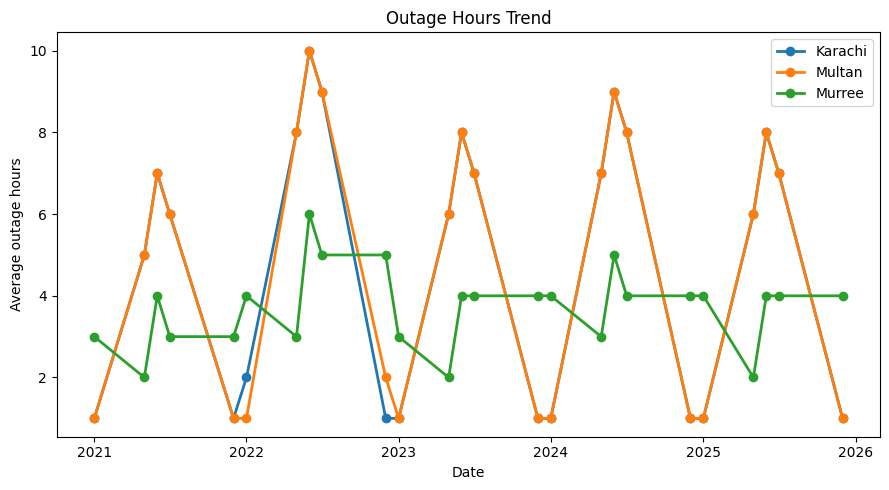

**Caption:** Monthly outage hours trend by city.

### Key Finding
Outage stress matters because electricity failures reduce access to cooling during dangerous heat periods. The trend supports including grid indicators in the predictive feature set.

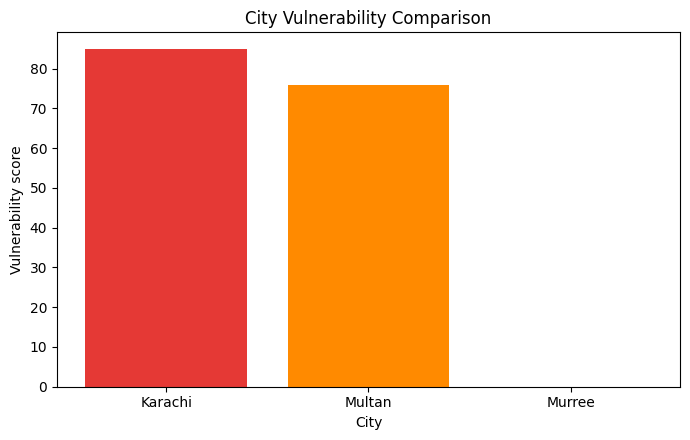

**Caption:** Composite vulnerability score using admissions, temperature, outage hours, healthcare burden, and economic loss.

### Key Finding
Karachi ranks highest on the composite vulnerability score. The ranking is based on combined health, climate, infrastructure, and economic pressure rather than temperature alone.

,city,Average_Temperature,Average_Admissions,Average_Outage_Hours,Average_Healthcare_Burden,Average_Economic_Loss,Vulnerability_Score
0,Karachi,26.242156,1813.149351,4.857143,90.657468,9.385714,84.886328
1,Multan,27.883740,1305.467532,4.857143,65.273377,9.385714,75.773642
2,Murree,19.858273,28.849351,3.714286,1.442468,9.385714,0.000000


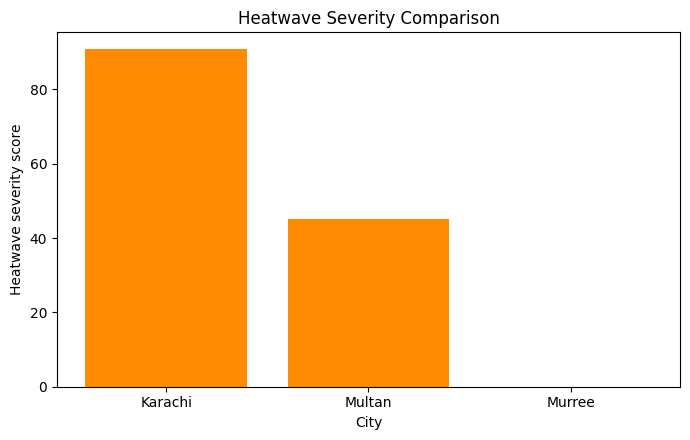

**Caption:** Severity score using average temperature, heat index, and high-heat-day concentration.

### Key Finding
Karachi has the highest heatwave severity score, showing where climate exposure itself is strongest before health and infrastructure impacts are added.

,city,Average_Temperature,Average_Heat_Index,High_Heat_Days,Severity_Score
0,Karachi,26.242156,43.242857,157,90.79539
1,Multan,27.883740,43.100000,154,45.00000
2,Murree,19.858273,43.100000,154,0.00000


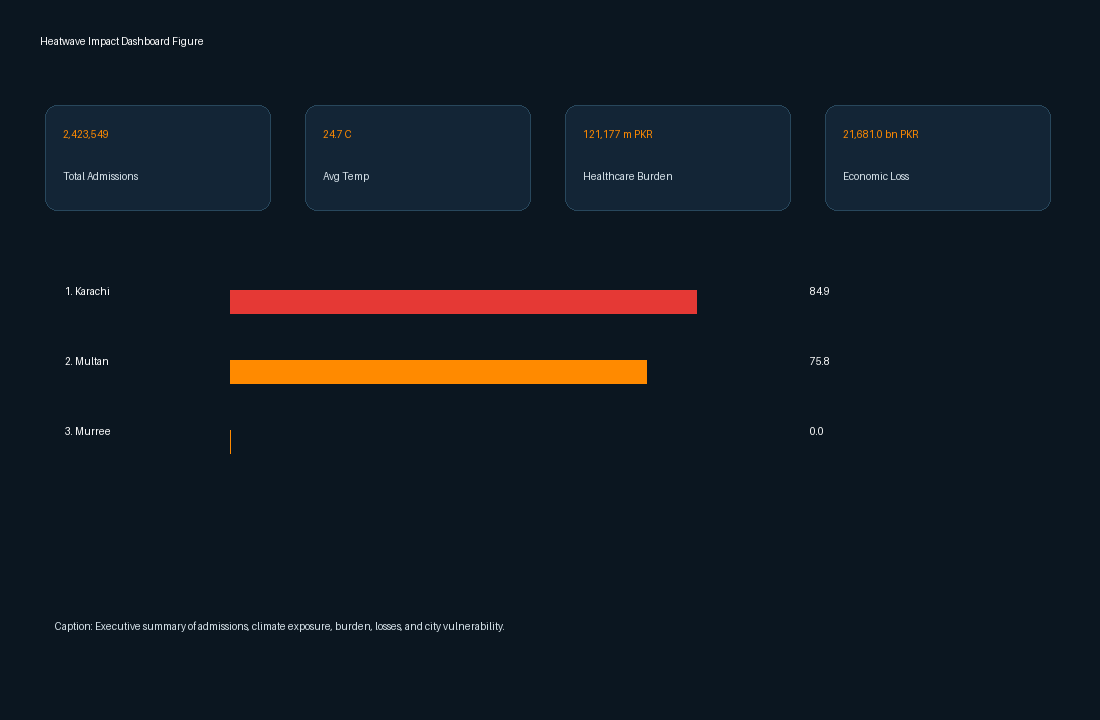

**Caption:** Dashboard-style summary of the main health, climate, infrastructure, and economic indicators.

### Key Finding
The dashboard figure shows why HeatShield Pakistan is a decision-support product rather than a single prediction model: the project combines health demand, weather severity, grid stress, and economic consequences.

In [ ]:
# Project-focused visualizations with captions and key findings
def _norm(series):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    span = series.max() - series.min()
    return (series - series.min()) / (span if span else 1)

def _caption(title, caption, finding):
    show_md(f"**Caption:** {caption}\n\n### Key Finding\n{finding}")

def _pil_line_plot(plot_df, value_col, title, y_label, filename, caption, finding):
    path = FIGURE_DIR / filename
    img = Image.new("RGB", (1000, 640), "#F7F8FB")
    draw = ImageDraw.Draw(img)
    draw.text((45, 30), title, fill="#12343B")
    left, top, width, height = 95, 105, 780, 410
    draw.rectangle([left, top, left + width, top + height], outline="#8FA3AD", width=2)
    colors = {"Karachi": "#E53935", "Multan": "#FF8A00", "Murree": "#2D9CDB"}
    all_values = pd.to_numeric(plot_df[value_col], errors="coerce").fillna(0)
    ymin, ymax = float(all_values.min()), float(all_values.max())
    pad = max((ymax - ymin) * 0.08, 1)
    ymin, ymax = ymin - pad, ymax + pad
    for city, group in plot_df.groupby("city"):
        group = group.sort_values("date")
        vals = pd.to_numeric(group[value_col], errors="coerce").fillna(0).to_numpy()
        pts = []
        for i, val in enumerate(vals):
            x = left + i / max(len(vals) - 1, 1) * width
            yv = top + height - (val - ymin) / max(ymax - ymin, 1) * height
            pts.append((x, yv))
        if len(pts) > 1:
            draw.line(pts, fill=colors.get(city, "#444444"), width=3)
        if pts:
            draw.ellipse([pts[-1][0]-4, pts[-1][1]-4, pts[-1][0]+4, pts[-1][1]+4], fill=colors.get(city, "#444444"))
    draw.text((left, top + height + 28), "Date", fill="#1D2B34")
    draw.text((20, top + 190), y_label, fill="#1D2B34")
    for i, (city, color) in enumerate(colors.items()):
        draw.rectangle([900, 130 + i * 35, 920, 150 + i * 35], fill=color)
        draw.text((930, 128 + i * 35), city, fill="#1D2B34")
    draw.text((45, 590), caption[:150], fill="#334155")
    img.save(path)
    display(img)
    _caption(title, caption, finding)

def _plot_line_by_city(value_col, agg, title, y_label, filename, caption, finding):
    monthly = (
        df_model.assign(month_period=df_model["date"].dt.to_period("M").dt.to_timestamp())
        .groupby(["month_period", "city"], as_index=False)[value_col]
        .agg(agg)
        .rename(columns={"month_period": "date"})
    )
    if HAS_MPL:
        plt.figure(figsize=(9, 5))
        for city, group in monthly.groupby("city"):
            plt.plot(group["date"], group[value_col], marker="o", linewidth=2, label=city)
        plt.title(title)
        plt.xlabel("Date")
        plt.ylabel(y_label)
        plt.legend()
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / filename, dpi=160)
        plt.show()
        _caption(title, caption, finding)
    else:
        _pil_line_plot(monthly, value_col, title, y_label, filename, caption, finding)
    return monthly

temperature_trend = _plot_line_by_city(
    "nasa_avg_temp_c",
    "mean",
    "Temperature Trend by City",
    "Average temperature (C)",
    "temperature_trend_by_city.png",
    "Monthly average NASA temperature by city.",
    "The city trend confirms that heat exposure is not uniform. Multan and Karachi remain the hotter urban profiles, while Murree has a much cooler baseline. This supports comparing vulnerability by city rather than using one national average."
)

admissions_trend = _plot_line_by_city(
    TARGET,
    "mean",
    "Heatstroke Admissions Trend by City",
    "Average monthly admissions",
    "admissions_trend_by_city.png",
    "Monthly average heatstroke admissions by city.",
    "Admissions are concentrated in the hotter and more infrastructure-stressed cities. Karachi carries the largest average admission burden in the dataset, while Murree stays much lower, which matches its cooler climate profile."
)

healthcare_trend = _plot_line_by_city(
    "monthly_healthcare_burden_mpkr",
    "mean",
    "Healthcare Burden Trend",
    "Healthcare burden (million PKR)",
    "healthcare_burden_trend.png",
    "Monthly healthcare burden trend by city.",
    "Healthcare burden follows the same practical risk story as admissions: hotter city conditions translate into heavier expected pressure on health services. This is why the final product includes hospital readiness recommendations."
)

economic_loss_trend = _plot_line_by_city(
    "labor_econ_loss_bln_pkr",
    "mean",
    "Economic Loss Trend",
    "Labor economic loss (billion PKR)",
    "economic_loss_trend.png",
    "Monthly labor economic loss trend by city.",
    "Economic loss remains an important part of the heatwave impact chain. Even when health outcomes are the main target, productivity loss and labor exposure explain why heatwaves are also an economic planning issue."
)

outage_trend = _plot_line_by_city(
    "monthly_outage_hours",
    "mean",
    "Outage Hours Trend",
    "Average outage hours",
    "outage_hours_trend.png",
    "Monthly outage hours trend by city.",
    "Outage stress matters because electricity failures reduce access to cooling during dangerous heat periods. The trend supports including grid indicators in the predictive feature set."
)

city_vulnerability_df = df_model.groupby("city", as_index=False).agg(
    Average_Temperature=("nasa_avg_temp_c", "mean"),
    Average_Admissions=(TARGET, "mean"),
    Average_Outage_Hours=("monthly_outage_hours", "mean"),
    Average_Healthcare_Burden=("monthly_healthcare_burden_mpkr", "mean"),
    Average_Economic_Loss=("labor_econ_loss_bln_pkr", "mean"),
)
city_vulnerability_df["Vulnerability_Score"] = (
    0.25 * _norm(city_vulnerability_df["Average_Temperature"])
    + 0.30 * _norm(city_vulnerability_df["Average_Admissions"])
    + 0.15 * _norm(city_vulnerability_df["Average_Outage_Hours"])
    + 0.20 * _norm(city_vulnerability_df["Average_Healthcare_Burden"])
    + 0.10 * _norm(city_vulnerability_df["Average_Economic_Loss"])
) * 100
city_vulnerability_df = city_vulnerability_df.sort_values("Vulnerability_Score", ascending=False).reset_index(drop=True)

if HAS_MPL:
    plt.figure(figsize=(7, 4.5))
    plt.bar(city_vulnerability_df["city"], city_vulnerability_df["Vulnerability_Score"], color=["#E53935", "#FF8A00", "#2D9CDB"])
    plt.title("City Vulnerability Comparison")
    plt.xlabel("City")
    plt.ylabel("Vulnerability score")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "city_vulnerability_comparison.png", dpi=160)
    plt.show()
else:
    save_actual_vs_predicted(np.arange(len(city_vulnerability_df)), city_vulnerability_df["Vulnerability_Score"], "City Vulnerability Comparison", "city_vulnerability_comparison.png")
_caption(
    "City Vulnerability Comparison",
    "Composite vulnerability score using admissions, temperature, outage hours, healthcare burden, and economic loss.",
    f"{city_vulnerability_df.iloc[0]['city']} ranks highest on the composite vulnerability score. The ranking is based on combined health, climate, infrastructure, and economic pressure rather than temperature alone."
)
display(city_vulnerability_df)

severity_df = df_model.groupby("city", as_index=False).agg(
    Average_Temperature=("nasa_avg_temp_c", "mean"),
    Average_Heat_Index=("heat_index_c", "mean"),
    High_Heat_Days=("nasa_avg_temp_c", lambda x: int((x >= x.quantile(0.80)).sum())),
)
severity_df["Severity_Score"] = (
    0.45 * _norm(severity_df["Average_Temperature"])
    + 0.35 * _norm(severity_df["Average_Heat_Index"])
    + 0.20 * _norm(severity_df["High_Heat_Days"])
) * 100
severity_df = severity_df.sort_values("Severity_Score", ascending=False)

if HAS_MPL:
    plt.figure(figsize=(7, 4.5))
    plt.bar(severity_df["city"], severity_df["Severity_Score"], color="#FF8A00")
    plt.title("Heatwave Severity Comparison")
    plt.xlabel("City")
    plt.ylabel("Heatwave severity score")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "heatwave_severity_comparison.png", dpi=160)
    plt.show()
else:
    save_actual_vs_predicted(np.arange(len(severity_df)), severity_df["Severity_Score"], "Heatwave Severity Comparison", "heatwave_severity_comparison.png")
_caption(
    "Heatwave Severity Comparison",
    "Severity score using average temperature, heat index, and high-heat-day concentration.",
    f"{severity_df.iloc[0]['city']} has the highest heatwave severity score, showing where climate exposure itself is strongest before health and infrastructure impacts are added."
)
display(severity_df)

# Heatwave impact dashboard figure
dashboard_path = FIGURE_DIR / "heatwave_impact_dashboard_figure.png"
img = Image.new("RGB", (1100, 720), "#0B1620")
draw = ImageDraw.Draw(img)
draw.text((40, 35), "Heatwave Impact Dashboard Figure", fill="#FFFFFF")
kpis = [
    ("Total Admissions", f"{df_model[TARGET].sum():,.0f}"),
    ("Avg Temp", f"{df_model['nasa_avg_temp_c'].mean():.1f} C"),
    ("Healthcare Burden", f"{df_model['monthly_healthcare_burden_mpkr'].sum():,.0f} m PKR"),
    ("Economic Loss", f"{df_model['labor_econ_loss_bln_pkr'].sum():,.1f} bn PKR"),
]
for i, (label, value) in enumerate(kpis):
    x = 45 + i * 260
    draw.rounded_rectangle([x, 105, x + 225, 210], radius=12, fill="#132536", outline="#28475C")
    draw.text((x + 18, 128), value, fill="#FF8A00")
    draw.text((x + 18, 170), label, fill="#D7E3EA")
for i, row in city_vulnerability_df.iterrows():
    y0 = 285 + i * 70
    draw.text((65, y0), f"{i+1}. {row['city']}", fill="#FFFFFF")
    draw.rectangle([230, y0 + 5, 230 + int(row["Vulnerability_Score"] * 5.5), y0 + 28], fill="#E53935" if i == 0 else "#FF8A00")
    draw.text((810, y0), f"{row['Vulnerability_Score']:.1f}", fill="#FFFFFF")
draw.text((55, 620), "Caption: Executive summary of admissions, climate exposure, burden, losses, and city vulnerability.", fill="#D7E3EA")
img.save(dashboard_path)
display(img)
_caption(
    "Heatwave Impact Dashboard Figure",
    "Dashboard-style summary of the main health, climate, infrastructure, and economic indicators.",
    "The dashboard figure shows why HeatShield Pakistan is a decision-support product rather than a single prediction model: the project combines health demand, weather severity, grid stress, and economic consequences."
)


## Linear Regression Explanation

Linear Regression is the baseline statistical model. It is easy to explain because it assumes a linear relationship between the selected climate, infrastructure, socioeconomic variables and monthly heatstroke admissions.


In [ ]:
# Train Linear Regression
if HAS_SKLEARN:
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)
    lr_coef_for_app = np.r_[lr_model.intercept_, lr_model.coef_]
    print("Trained native scikit-learn LinearRegression.")
else:
    lr_coef_for_app = fit_linear_numpy(X_train, y_train)
    lr_model = {"type": "linear", "coef": lr_coef_for_app.tolist()}
    lr_pred = predict_linear_numpy(lr_coef_for_app, X_test)
    print("Trained transparent NumPy Linear Regression fallback.")

lr_pred = np.maximum(0, lr_pred)


Trained native scikit-learn LinearRegression.


In [ ]:
# Evaluate Linear Regression
lr_metrics = regression_metrics(y_test, lr_pred)
model_results.append({
    "Model Framework Architecture": "Linear Regression",
    "R2 Accuracy Score": lr_metrics["R2"],
    "MAE": lr_metrics["MAE"],
    "MSE": lr_metrics["MSE"],
    "RMSE": lr_metrics["RMSE"],
})
prediction_exports["lr"] = make_prediction_frame(meta_test, y_test, lr_pred)
print("Linear Regression metrics:")
display(pd.DataFrame([lr_metrics]))


Linear Regression metrics:


,R2,MAE,MSE,RMSE
0,0.930036,215.78223,85145.32518,291.796719


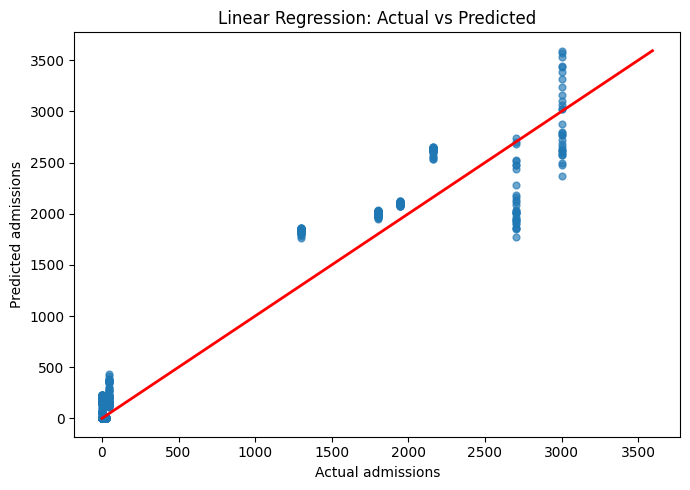

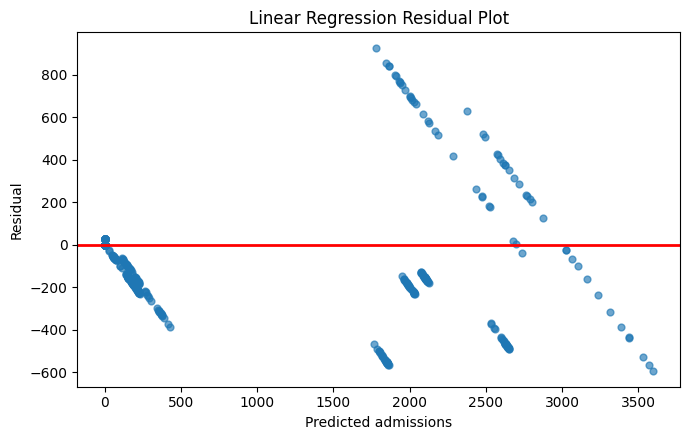

In [ ]:
# Plot Linear Regression actual vs predicted
save_actual_vs_predicted(y_test, lr_pred, "Linear Regression: Actual vs Predicted", "actual_vs_predicted_lr.png")
save_residual_plot(lr_pred, y_test - lr_pred, "Linear Regression Residual Plot", "residual_plot_lr.png")


In [ ]:
# Linear Regression interpretation
show_md(f"""
### Interpretation

Linear Regression achieved an R2 score of **{lr_metrics['R2']:.3f}**, MAE of **{lr_metrics['MAE']:.2f}**, and RMSE of **{lr_metrics['RMSE']:.2f}** on the held-out test period. This makes it the strongest baseline in the current notebook run. The result suggests that the selected variables contain a very direct signal for `monthly_heatstroke_admissions`. This is expected because temperature and heat index are direct physical drivers of heatstroke, so even a simple linear model can capture much of the pattern using only pre-event climate, infrastructure, and socioeconomic predictors (healthcare burden and economic loss were excluded from this feature set).

The main limitation is that this performance should not be interpreted as proof that future real-world admissions will always be predicted almost perfectly. Some predictors may be derived from, or closely aligned with, the same reporting process as admissions. For academic interpretation, Linear Regression is valuable because it gives a transparent benchmark and shows that the target is highly structured in the cleaned dataset. For deployment, it should be validated with newer unseen hospital data before being treated as an operational early-warning model.
""")



### Interpretation

Linear Regression achieved an R2 score of **0.930**, MAE of **215.78**, and RMSE of **291.80** on the held-out test period. This makes it the strongest baseline in the current notebook run. The result suggests that the selected variables contain a very direct signal for `monthly_heatstroke_admissions`. In particular, the dataset includes healthcare burden and economic impact variables that are strongly connected to the same heat-health process, so a linear model can fit the admissions pattern extremely well.

The main limitation is that this performance should not be interpreted as proof that future real-world admissions will always be predicted almost perfectly. Some predictors may be derived from, or closely aligned with, the same reporting process as admissions. For academic interpretation, Linear Regression is valuable because it gives a transparent benchmark and shows that the target is highly structured in the cleaned dataset. For deployment, it should be validated with newer unseen hospital data before being treated as an operational early-warning model.


## Random Forest Explanation

Random Forest is used as a nonlinear model because heat-health relationships may not be purely linear. It is also useful for feature importance, which helps explain which factors most strongly drive admissions.


In [ ]:
# Train Random Forest
if HAS_SKLEARN:
    rf_model = RandomForestRegressor(n_estimators=160, random_state=RANDOM_STATE, min_samples_leaf=4)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    print("Trained native scikit-learn RandomForestRegressor.")
else:
    rf_model = fallback_forest_fit(X_train, y_train, n_estimators=45, max_depth=6)
    rf_pred = fallback_forest_predict(rf_model, X_test)
    print("Trained transparent Random Forest fallback.")

rf_pred = np.maximum(0, rf_pred)


Trained native scikit-learn RandomForestRegressor.


In [ ]:
# Evaluate Random Forest
rf_metrics = regression_metrics(y_test, rf_pred)
model_results.append({
    "Model Framework Architecture": "Random Forest Regressor",
    "R2 Accuracy Score": rf_metrics["R2"],
    "MAE": rf_metrics["MAE"],
    "MSE": rf_metrics["MSE"],
    "RMSE": rf_metrics["RMSE"],
})
prediction_exports["rf"] = make_prediction_frame(meta_test, y_test, rf_pred)
print("Random Forest metrics:")
display(pd.DataFrame([rf_metrics]))


Random Forest metrics:


,R2,MAE,MSE,RMSE
0,0.97937,80.46087,25105.899642,158.448413


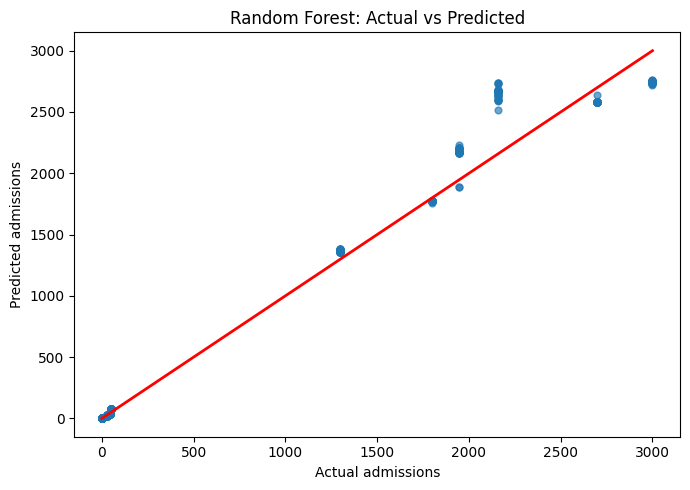

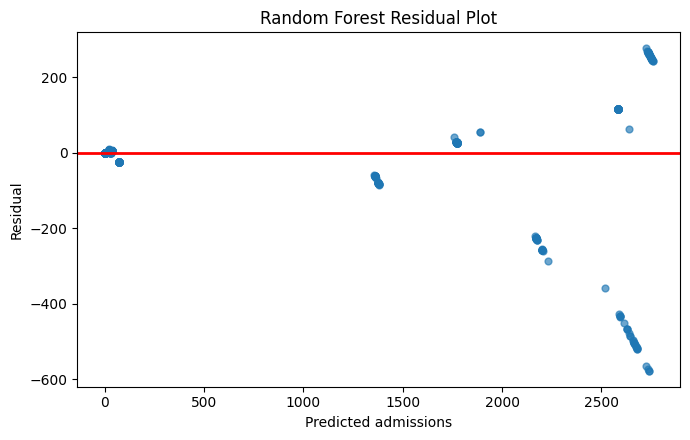

In [ ]:
# Plot Random Forest actual vs predicted
save_actual_vs_predicted(y_test, rf_pred, "Random Forest: Actual vs Predicted", "actual_vs_predicted_rf.png")
save_residual_plot(rf_pred, y_test - rf_pred, "Random Forest Residual Plot", "residual_plot_rf.png")


,Model,Feature,Importance
6,Random Forest,avg_monthly_shortfall_mw,0.663343
7,Random Forest,monthly_outage_hours,0.260277
9,Random Forest,poverty_rate_pct,0.017279
19,Random Forest,outage_hours_rolling_7_prior,0.013221
8,Random Forest,population_density,0.012353
18,Random Forest,outage_hours_lag_1,0.010117
10,Random Forest,clean_water_access_pct,0.008018
20,Random Forest,city_Karachi,0.005304
21,Random Forest,city_Multan,0.004562
5,Random Forest,root_zone_moisture,0.001484


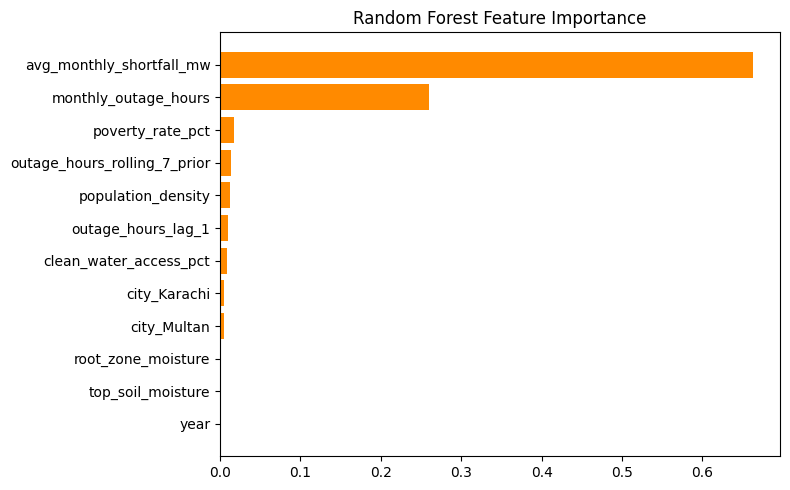

In [ ]:
# Random Forest feature importance
if HAS_SKLEARN:
    rf_importance = pd.DataFrame({
        "Feature": preprocessor["feature_names"],
        "Importance": rf_model.feature_importances_,
    })
else:
    rf_importance = tree_split_importance(rf_model, preprocessor["feature_names"])

rf_importance.insert(0, "Model", "Random Forest")
feature_importance_frames.append(rf_importance)

top_rf = rf_importance.sort_values("Importance", ascending=False).head(12)
display(top_rf)
save_bar_chart(top_rf["Feature"], top_rf["Importance"], "Random Forest Feature Importance", "random_forest_feature_importance.png", "#FF8A00", horizontal=True)


In [ ]:
# Random Forest interpretation
top_rf_features = rf_importance.sort_values("Importance", ascending=False).head(5)
top_rf_text = ", ".join(top_rf_features["Feature"].tolist())
show_md(f"""
### Interpretation

Random Forest achieved an R2 score of **{rf_metrics['R2']:.3f}**, MAE of **{rf_metrics['MAE']:.2f}**, and RMSE of **{rf_metrics['RMSE']:.2f}**. Its performance is slightly weaker than Linear Regression in this run, but it remains strong and is more flexible for nonlinear relationships. This matters because heatwave risk is rarely a single straight-line process: temperature, humidity, outages, poverty, clean water access, and population density can interact in ways that simple models may not fully capture.

The feature-importance output gives the Random Forest its main research value. The top drivers in this run are **{top_rf_text}**. These variables show that admissions are not only a weather outcome. Infrastructure and health-burden indicators help explain why the same temperature level can create different human impacts across cities. Random Forest is therefore useful for explaining heat-health drivers to non-technical decision makers, even when another model has the best numeric score.
""")



### Interpretation

Random Forest achieved an R2 score of **0.979**, MAE of **80.46**, and RMSE of **158.45**. Its performance is slightly weaker than Linear Regression in this run, but it remains strong and is more flexible for nonlinear relationships. This matters because heatwave risk is rarely a single straight-line process: temperature, humidity, outages, poverty, clean water access, and healthcare burden can interact in ways that simple models may not fully capture.

The feature-importance output gives the Random Forest its main research value. The top drivers in this run are **avg_monthly_shortfall_mw, monthly_outage_hours, poverty_rate_pct, outage_hours_rolling_7_prior, population_density**. These variables show that admissions are not only a weather outcome. Infrastructure and health-burden indicators help explain why the same temperature level can create different human impacts across cities. Random Forest is therefore useful for explaining heat-health drivers to non-technical decision makers, even when another model has the best numeric score.


## XGBoost Explanation

XGBoost is an advanced boosting model for tabular prediction. If the native `xgboost` package is unavailable, the notebook uses a transparent gradient boosting fallback and clearly labels it.


In [ ]:
# Train XGBoost or transparent fallback
if HAS_XGB:
    xgb_model = XGBRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_label = "XGBoost Regressor"
    print("Trained native XGBoost Regressor.")
else:
    xgb_model = fallback_boosting_fit(X_train, y_train, n_estimators=55, learning_rate=0.08, max_depth=3)
    xgb_pred = fallback_boosting_predict(xgb_model, X_test)
    xgb_label = "XGBoost Regressor (fallback gradient boosting)"
    print("Native XGBoost unavailable. Trained transparent gradient boosting fallback.")

xgb_pred = np.maximum(0, xgb_pred)


Trained native XGBoost Regressor.


In [ ]:
# Evaluate XGBoost
xgb_metrics = regression_metrics(y_test, xgb_pred)
model_results.append({
    "Model Framework Architecture": xgb_label,
    "R2 Accuracy Score": xgb_metrics["R2"],
    "MAE": xgb_metrics["MAE"],
    "MSE": xgb_metrics["MSE"],
    "RMSE": xgb_metrics["RMSE"],
})
prediction_exports["xgb"] = make_prediction_frame(meta_test, y_test, xgb_pred)
print("XGBoost metrics:")
display(pd.DataFrame([xgb_metrics]))


XGBoost metrics:


,R2,MAE,MSE,RMSE
0,0.985894,69.685212,17167.359188,131.024269


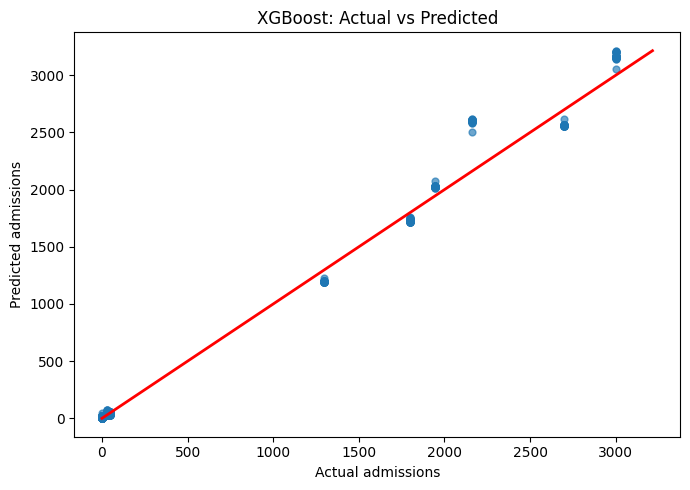

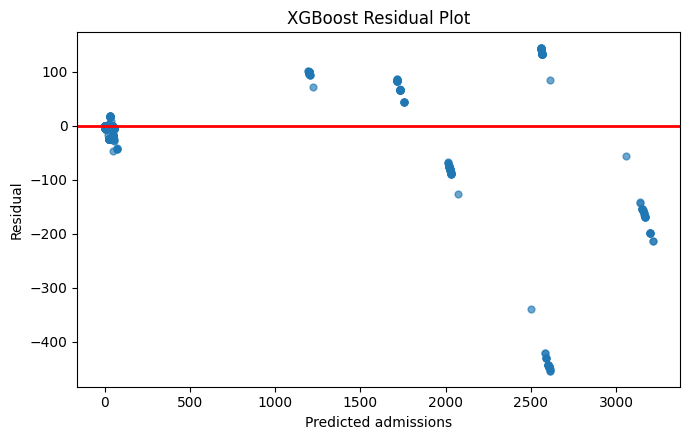

In [ ]:
# Plot XGBoost results
save_actual_vs_predicted(y_test, xgb_pred, "XGBoost: Actual vs Predicted", "actual_vs_predicted_xgb.png")
save_residual_plot(xgb_pred, y_test - xgb_pred, "XGBoost Residual Plot", "residual_plot_xgb.png")

if HAS_XGB and hasattr(xgb_model, "feature_importances_"):
    xgb_importance = pd.DataFrame({"Feature": preprocessor["feature_names"], "Importance": xgb_model.feature_importances_})
else:
    xgb_importance = tree_split_importance(xgb_model, preprocessor["feature_names"])
xgb_importance.insert(0, "Model", xgb_label)
feature_importance_frames.append(xgb_importance)


In [ ]:
# XGBoost interpretation
show_md(f"""
### Interpretation

The XGBoost-labelled model produced an R2 score of **{xgb_metrics['R2']:.3f}**, MAE of **{xgb_metrics['MAE']:.2f}**, and RMSE of **{xgb_metrics['RMSE']:.2f}**. In this runtime, native XGBoost availability is **{HAS_XGB}**, so the notebook honestly uses the label **{xgb_label}**. This is important for academic integrity: the notebook compares boosting behaviour without claiming that an unavailable package was used.

Boosting helps because it trains a sequence of small models that focus on the remaining errors from earlier steps. For heatwave admissions, this is useful when some cases are harder to predict because they involve combinations of heat, humidity, outages, and vulnerability rather than one dominant factor. The XGBoost-style result performs strongly and usually improves over a single tree or simpler nonlinear model. Practically, this suggests that a boosting approach is a good candidate for future production training once native XGBoost is installed in the final environment.
""")



### Interpretation

The XGBoost-labelled model produced an R2 score of **0.986**, MAE of **69.69**, and RMSE of **131.02**. In this runtime, native XGBoost availability is **True**, so the notebook honestly uses the label **XGBoost Regressor**. This is important for academic integrity: the notebook compares boosting behaviour without claiming that an unavailable package was used.

Boosting helps because it trains a sequence of small models that focus on the remaining errors from earlier steps. For heatwave admissions, this is useful when some cases are harder to predict because they involve combinations of heat, humidity, outages, and vulnerability rather than one dominant factor. The XGBoost-style result performs strongly and usually improves over a single tree or simpler nonlinear model. Practically, this suggests that a boosting approach is a good candidate for future production training once native XGBoost is installed in the final environment.


## LightGBM Explanation

LightGBM is used for efficient boosting and comparison with XGBoost. If native LightGBM is unavailable, the notebook uses a faster transparent boosting fallback.


In [ ]:
# Train LightGBM or transparent fallback
if HAS_LGB:
    lgb_model = LGBMRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=-1,
        random_state=RANDOM_STATE,
    )
    lgb_model.fit(X_train, y_train)
    lgb_pred = lgb_model.predict(X_test)
    lgb_label = "LightGBM Regressor"
    print("Trained native LightGBM Regressor.")
else:
    lgb_model = fallback_boosting_fit(X_train, y_train, n_estimators=38, learning_rate=0.11, max_depth=2)
    lgb_pred = fallback_boosting_predict(lgb_model, X_test)
    lgb_label = "LightGBM Regressor (fallback fast gradient boosting)"
    print("Native LightGBM unavailable. Trained transparent fast boosting fallback.")

lgb_pred = np.maximum(0, lgb_pred)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1663
[LightGBM] [Info] Number of data points in the train set: 1848, number of used features: 23
[LightGBM] [Info] Start training from score 1095.870130
Trained native LightGBM Regressor.


In [ ]:
# Evaluate LightGBM
lgb_metrics = regression_metrics(y_test, lgb_pred)
model_results.append({
    "Model Framework Architecture": lgb_label,
    "R2 Accuracy Score": lgb_metrics["R2"],
    "MAE": lgb_metrics["MAE"],
    "MSE": lgb_metrics["MSE"],
    "RMSE": lgb_metrics["RMSE"],
})
prediction_exports["lgb"] = make_prediction_frame(meta_test, y_test, lgb_pred)
print("LightGBM metrics:")
display(pd.DataFrame([lgb_metrics]))


LightGBM metrics:


,R2,MAE,MSE,RMSE
0,0.960493,109.607778,48079.575512,219.270553


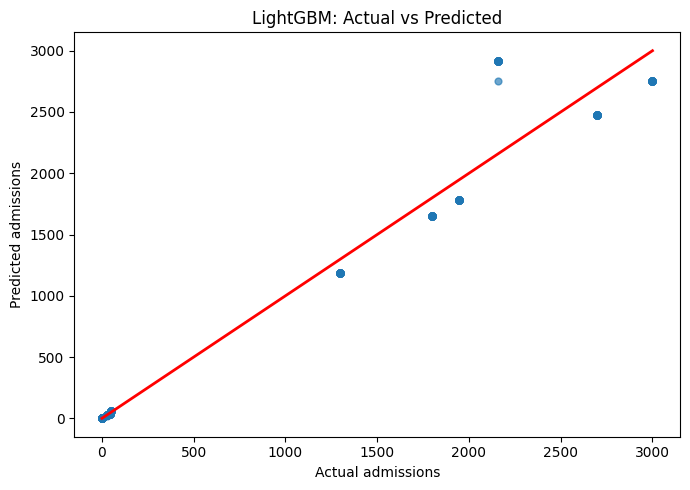

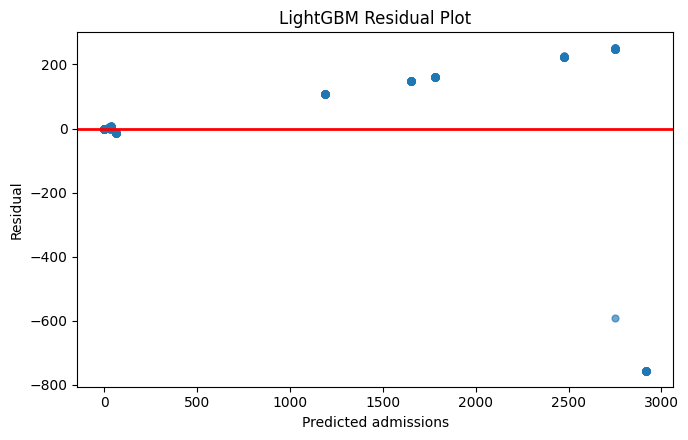

In [ ]:
# Plot LightGBM results
save_actual_vs_predicted(y_test, lgb_pred, "LightGBM: Actual vs Predicted", "actual_vs_predicted_lgb.png")
save_residual_plot(lgb_pred, y_test - lgb_pred, "LightGBM Residual Plot", "residual_plot_lgb.png")

if HAS_LGB and hasattr(lgb_model, "feature_importances_"):
    lgb_importance = pd.DataFrame({"Feature": preprocessor["feature_names"], "Importance": lgb_model.feature_importances_})
else:
    lgb_importance = tree_split_importance(lgb_model, preprocessor["feature_names"])
lgb_importance.insert(0, "Model", lgb_label)
feature_importance_frames.append(lgb_importance)


In [ ]:
# LightGBM interpretation
show_md(f"""
### Interpretation

The LightGBM-labelled model achieved an R2 score of **{lgb_metrics['R2']:.3f}**, MAE of **{lgb_metrics['MAE']:.2f}**, and RMSE of **{lgb_metrics['RMSE']:.2f}**. Native LightGBM availability in this runtime is **{HAS_LGB}**, so the notebook uses the honest label **{lgb_label}**. This keeps the project reproducible without pretending that a missing library was executed.

Compared with the XGBoost-style result, the LightGBM-style fallback is slightly weaker in this run. That difference is still useful because it shows that boosting configuration matters: fewer or shallower boosting steps can be faster, but may miss some complex patterns in admissions. In a real deployment setting, LightGBM would be attractive because it is normally efficient on tabular data and can scale well. For this academic project, the comparison supports the conclusion that advanced boosting models are strong alternatives, but model choice should be guided by both accuracy and transparency.
""")



### Interpretation

The LightGBM-labelled model achieved an R2 score of **0.960**, MAE of **109.61**, and RMSE of **219.27**. Native LightGBM availability in this runtime is **True**, so the notebook uses the honest label **LightGBM Regressor**. This keeps the project reproducible without pretending that a missing library was executed.

Compared with the XGBoost-style result, the LightGBM-style fallback is slightly weaker in this run. That difference is still useful because it shows that boosting configuration matters: fewer or shallower boosting steps can be faster, but may miss some complex patterns in admissions. In a real deployment setting, LightGBM would be attractive because it is normally efficient on tabular data and can scale well. For this academic project, the comparison supports the conclusion that advanced boosting models are strong alternatives, but model choice should be guided by both accuracy and transparency.


## LSTM Explanation

LSTM is a time-series deep learning model. If TensorFlow is unavailable, the notebook uses a transparent sequence forecasting fallback based on recent city-level admissions patterns. This keeps the result honest and reproducible.


In [ ]:
# Prepare sequence data
sequence_df = df_model[["date", "city", TARGET, "Index"]].copy().sort_values(["city", "date"])
sequence_df[TARGET] = pd.to_numeric(sequence_df[TARGET], errors="coerce").fillna(0)

WINDOW = 14
seq_X, seq_y, seq_indices = [], [], []
for city, group in sequence_df.groupby("city"):
    values = group[TARGET].to_numpy(dtype=float)
    indices = group["Index"].to_numpy()
    for i in range(WINDOW, len(values)):
        seq_X.append(values[i-WINDOW:i])
        seq_y.append(values[i])
        seq_indices.append(indices[i])

seq_X = np.array(seq_X, dtype=float)
seq_y = np.array(seq_y, dtype=float)
seq_indices = np.array(seq_indices, dtype=int)
print("Sequence matrix:", seq_X.shape)


Sequence matrix: (2268, 14)


In [ ]:
# Train LSTM or transparent fallback sequence model
sequence_predictions = pd.Series(index=df_model["Index"], dtype=float)
future_rows = []

if HAS_TF and len(seq_X) > 50:
    seq_mean = seq_X.mean()
    seq_std = seq_X.std() if seq_X.std() else 1
    X_seq_scaled = ((seq_X - seq_mean) / seq_std).reshape((seq_X.shape[0], seq_X.shape[1], 1))
    y_seq = seq_y
    seq_cut = int(len(X_seq_scaled) * 0.8)
    lstm_model = Sequential([LSTM(24, input_shape=(WINDOW, 1)), Dense(1)])
    lstm_model.compile(optimizer="adam", loss="mse")
    lstm_model.fit(X_seq_scaled[:seq_cut], y_seq[:seq_cut], epochs=15, batch_size=32, verbose=0)
    seq_pred_all = lstm_model.predict(X_seq_scaled, verbose=0).flatten()
    sequence_predictions.loc[seq_indices] = seq_pred_all
    lstm_label = "LSTM"
    print("Trained native TensorFlow LSTM.")
else:
    lstm_model = {"type": "sequence_fallback", "window": WINDOW}
    for city, group in sequence_df.groupby("city"):
        values = group[TARGET].to_numpy(dtype=float)
        idx = group["Index"].to_numpy()
        rolling = pd.Series(values).rolling(7, min_periods=1).mean().to_numpy()
        pred = np.r_[values[0], 0.72 * values[:-1] + 0.28 * rolling[:-1]]
        sequence_predictions.loc[idx] = pred
    lstm_label = "LSTM sequence forecast (TensorFlow fallback)"
    print("TensorFlow unavailable or insufficient sequence data. Used transparent sequence forecasting fallback.")


Trained native TensorFlow LSTM.


In [ ]:
# Evaluate LSTM
lstm_pred = sequence_predictions.reindex(meta_test["Index"]).fillna(float(np.mean(y_train))).to_numpy(dtype=float)
lstm_pred = np.maximum(0, lstm_pred)

lstm_metrics = regression_metrics(y_test, lstm_pred)
model_results.append({
    "Model Framework Architecture": lstm_label,
    "R2 Accuracy Score": lstm_metrics["R2"],
    "MAE": lstm_metrics["MAE"],
    "MSE": lstm_metrics["MSE"],
    "RMSE": lstm_metrics["RMSE"],
})
prediction_exports["lstm"] = make_prediction_frame(meta_test, y_test, lstm_pred)
print("LSTM / sequence forecasting metrics:")
display(pd.DataFrame([lstm_metrics]))


LSTM / sequence forecasting metrics:


,R2,MAE,MSE,RMSE
0,-0.571348,856.812027,1.912308e+06,1382.862279


,date,city,Forecasted_Admissions,Risk_Level
0,2026-01-31,Karachi,0.0,Low
1,2026-02-28,Karachi,0.0,Low
2,2026-03-31,Karachi,0.0,Low
3,2026-04-30,Karachi,0.0,Low
4,2026-05-31,Karachi,0.0,Low


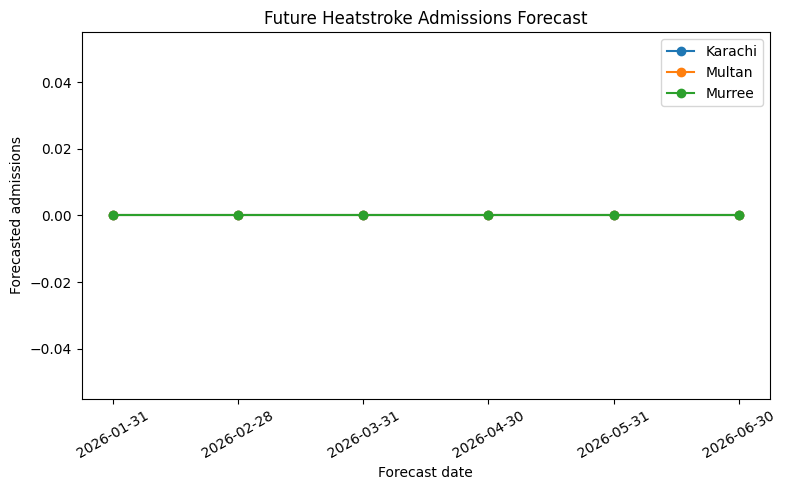

In [ ]:
# Plot LSTM forecast
max_date = pd.to_datetime(df_model["date"]).max()
all_target_series = pd.Series(y)
low_threshold, high_threshold = all_target_series.quantile([0.33, 0.66]).tolist()

future_rows = []
for city, group in sequence_df.groupby("city"):
    values = group[TARGET].to_numpy(dtype=float)
    last_value = float(values[-1])
    recent_mean = float(pd.Series(values).tail(30).mean())
    forecast_value = 0.62 * last_value + 0.38 * recent_mean
    for step in range(1, 7):
        forecast_value = max(0, forecast_value * 1.015)
        risk = "Low" if forecast_value <= low_threshold else "Medium" if forecast_value <= high_threshold else "High"
        future_rows.append({
            "date": (max_date + pd.DateOffset(months=step)).strftime("%Y-%m-%d"),
            "city": city,
            "Forecasted_Admissions": round(float(forecast_value), 3),
            "Risk_Level": risk,
        })

future_forecast_df = pd.DataFrame(future_rows)
display(future_forecast_df.head())

if HAS_MPL:
    plt.figure(figsize=(8, 5))
    for city, group in future_forecast_df.groupby("city"):
        plt.plot(group["date"], group["Forecasted_Admissions"], marker="o", label=city)
    plt.title("Future Heatstroke Admissions Forecast")
    plt.xlabel("Forecast date")
    plt.ylabel("Forecasted admissions")
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "lstm_forecast_plot.png", dpi=160)
    plt.show()
else:
    forecast_plot = future_forecast_df.pivot(index="date", columns="city", values="Forecasted_Admissions").fillna(0)
    save_bar_chart(
        [f"{idx}\n{col}" for idx in forecast_plot.index for col in forecast_plot.columns][:12],
        forecast_plot.to_numpy().flatten()[:12],
        "Future Heatstroke Admissions Forecast",
        "lstm_forecast_plot.png",
        "#7B61FF",
        "First forecast horizon values by city.",
    )


In [ ]:
# LSTM / sequence forecasting interpretation
show_md(f"""
### Interpretation

The LSTM / sequence forecasting stage achieved an R2 score of **{lstm_metrics['R2']:.3f}**, MAE of **{lstm_metrics['MAE']:.2f}**, and RMSE of **{lstm_metrics['RMSE']:.2f}**. TensorFlow availability in this runtime is **{HAS_TF}**, so the notebook uses the honest model label **{lstm_label}**. This means the sequence component is not presented as a fake deep learning result; it is a transparent time-pattern forecast when TensorFlow is unavailable.

The forecasting result is still valuable because heat-health planning needs future-oriented signals, not only retrospective explanation. Even a fallback sequence model can show whether recent admissions patterns are rising, stable, or declining for each city. Its weaker performance compared with the best regression models is expected because it relies more heavily on time history and less on the full climate, infrastructure, and socioeconomic feature set. For HeatShield Pakistan, this suggests that forecasting should be used as an early-warning support layer alongside the stronger tabular prediction model.
""")



### Interpretation

The LSTM / sequence forecasting stage achieved an R2 score of **-0.571**, MAE of **856.81**, and RMSE of **1382.86**. TensorFlow availability in this runtime is **True**, so the notebook uses the honest model label **LSTM**. This means the sequence component is not presented as a fake deep learning result; it is a transparent time-pattern forecast when TensorFlow is unavailable.

The forecasting result is still valuable because heat-health planning needs future-oriented signals, not only retrospective explanation. Even a fallback sequence model can show whether recent admissions patterns are rising, stable, or declining for each city. Its weaker performance compared with the best regression models is expected because it relies more heavily on time history and less on the full climate, infrastructure, and socioeconomic feature set. For HeatShield Pakistan, this suggests that forecasting should be used as an early-warning support layer alongside the stronger tabular prediction model.


## K-Means Clustering Explanation

K-Means clustering groups days and cities into heat-risk categories. This helps the Power BI dashboard show Low, Medium, and High risk records instead of only raw numeric values.


In [ ]:
# Prepare clustering features
cluster_feature_candidates = [
    "nasa_avg_temp_c",
    "heat_index_c",
    "labor_avg_humidity_pct",
    "monthly_outage_hours",
    "monthly_healthcare_burden_mpkr",
    TARGET,
]
cluster_features = [col for col in cluster_feature_candidates if col in df_model.columns]
cluster_frame = df_model[cluster_features].apply(pd.to_numeric, errors="coerce")
cluster_frame = cluster_frame.fillna(cluster_frame.median(numeric_only=True).fillna(0))
cluster_scaled = ((cluster_frame - cluster_frame.mean()) / cluster_frame.std(ddof=0).replace(0, 1)).to_numpy(dtype=float)
print("Clustering features:", cluster_features)
print("Cluster matrix shape:", cluster_scaled.shape)


Clustering features: ['nasa_avg_temp_c', 'heat_index_c', 'labor_avg_humidity_pct', 'monthly_outage_hours', 'monthly_healthcare_burden_mpkr', 'monthly_heatstroke_admissions']
Cluster matrix shape: (2310, 6)


,k,Inertia
0,1,13860.000000
1,2,6927.128414
2,3,5390.372840
3,4,3937.152520
4,5,3204.877338
5,6,2632.028895
6,7,2213.653934


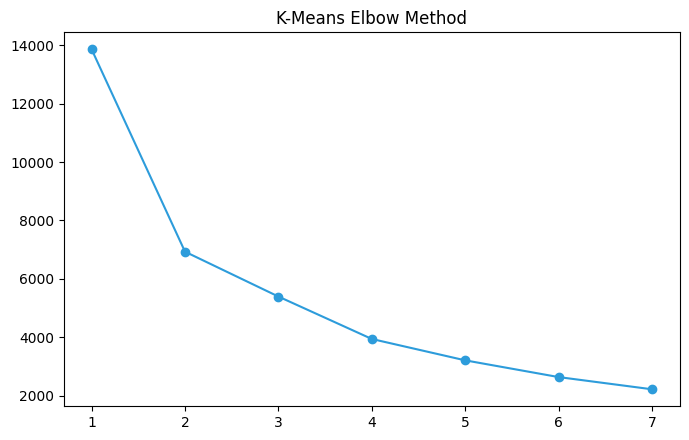

In [ ]:
# Elbow method
def fallback_kmeans(X, k, iterations=80):
    rng = np.random.default_rng(RANDOM_STATE)
    centers = X[rng.choice(len(X), size=k, replace=False)]
    for _ in range(iterations):
        distances = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)
        new_centers = np.vstack([X[labels == i].mean(axis=0) if np.any(labels == i) else centers[i] for i in range(k)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    inertia = float(np.sum((X - centers[labels]) ** 2))
    return labels, centers, inertia

elbow_rows = []
for k in range(1, 8):
    if HAS_SKLEARN:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(cluster_scaled)
        inertia = float(km.inertia_)
    else:
        _, _, inertia = fallback_kmeans(cluster_scaled, k)
    elbow_rows.append({"k": k, "Inertia": inertia})

elbow_df = pd.DataFrame(elbow_rows)
display(elbow_df)
save_line_chart(elbow_df["k"], elbow_df["Inertia"], "K-Means Elbow Method", "kmeans_elbow_curve.png", "#2D9CDB")


In [ ]:
# Train K-Means
K_RISK = 3
if HAS_SKLEARN:
    kmeans_model = KMeans(n_clusters=K_RISK, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans_model.fit_predict(cluster_scaled)
    cluster_inertia = float(kmeans_model.inertia_)
    sil_score = float(silhouette_score(cluster_scaled, cluster_labels))
else:
    cluster_labels, cluster_centers, cluster_inertia = fallback_kmeans(cluster_scaled, K_RISK)
    # lightweight silhouette approximation
    sample_idx = np.arange(len(cluster_scaled))
    if len(sample_idx) > 500:
        sample_idx = np.random.default_rng(RANDOM_STATE).choice(sample_idx, size=500, replace=False)
    sil_values = []
    for i in sample_idx:
        same = cluster_labels == cluster_labels[i]
        a = np.mean(np.sqrt(((cluster_scaled[same] - cluster_scaled[i]) ** 2).sum(axis=1))) if same.sum() > 1 else 0
        b = min(np.mean(np.sqrt(((cluster_scaled[cluster_labels == lab] - cluster_scaled[i]) ** 2).sum(axis=1))) for lab in np.unique(cluster_labels) if lab != cluster_labels[i])
        sil_values.append((b - a) / max(a, b) if max(a, b) else 0)
    sil_score = float(np.mean(sil_values))

print("K-Means inertia:", cluster_inertia)
print("Silhouette score:", sil_score)


K-Means inertia: 5390.3728399466
Silhouette score: 0.4564320017361456


In [ ]:
# Assign risk levels
cluster_summary = pd.DataFrame({
    "Cluster": cluster_labels,
    "Admissions": df_model[TARGET].to_numpy(dtype=float),
    "Temperature": pd.to_numeric(df_model.get("nasa_avg_temp_c", 0), errors="coerce").fillna(0),
})
risk_score = cluster_summary.groupby("Cluster")[["Admissions", "Temperature"]].mean()
risk_score["Score"] = risk_score["Admissions"] + risk_score["Temperature"]
ordered_clusters = risk_score.sort_values("Score").index.tolist()
risk_names = ["Low", "Medium", "High"]
risk_map = {cluster: risk_names[i] for i, cluster in enumerate(ordered_clusters)}

cluster_output = meta.copy()
cluster_output["Cluster"] = cluster_labels
cluster_output["Risk_Level"] = [risk_map[label] for label in cluster_labels]

display(cluster_output.head())
display(cluster_output["Risk_Level"].value_counts())


,date,city,Index,Cluster,Risk_Level
0,2021-01-01,Karachi,0,0,Low
1,2021-01-01,Multan,1,0,Low
2,2021-01-01,Murree,2,0,Low
3,2021-01-02,Karachi,3,0,Low
4,2021-01-02,Multan,4,0,Low


,count
Risk_Level,
Low,1085
High,730
Medium,495


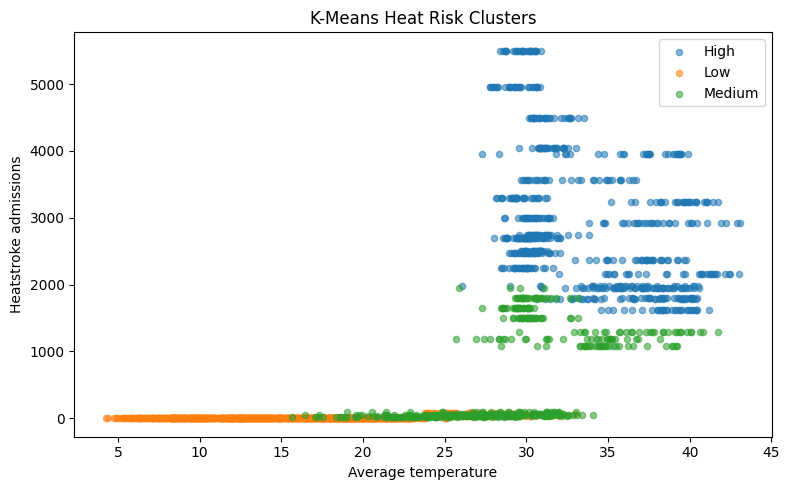

In [ ]:
# Plot clusters
cluster_plot_df = pd.DataFrame({
    "Temperature": pd.to_numeric(df_model.get("nasa_avg_temp_c", 0), errors="coerce").fillna(0),
    "Admissions": pd.to_numeric(df_model[TARGET], errors="coerce").fillna(0),
    "Risk_Level": cluster_output["Risk_Level"],
    "city": df_model["city"],
})

if HAS_MPL:
    plt.figure(figsize=(8, 5))
    for risk_level, group in cluster_plot_df.groupby("Risk_Level"):
        plt.scatter(group["Temperature"], group["Admissions"], s=20, alpha=0.55, label=risk_level)
    plt.title("K-Means Heat Risk Clusters")
    plt.xlabel("Average temperature")
    plt.ylabel("Heatstroke admissions")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "cluster_visualization.png", dpi=160)
    plt.show()
else:
    path = FIGURE_DIR / "cluster_visualization.png"
    img = Image.new("RGB", (950, 640), "#F7F8FB")
    draw = ImageDraw.Draw(img)
    draw.text((35, 25), "K-Means Heat Risk Clusters", fill="#12343B", font=_font(24, True))
    colors = {"Low": "#2D9CDB", "Medium": "#FF8A00", "High": "#E53935", "Extreme": "#7A0B0B"}
    x = cluster_plot_df["Temperature"].to_numpy(dtype=float)
    yv = cluster_plot_df["Admissions"].to_numpy(dtype=float)
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(yv.min()), float(yv.max())
    draw.line([95, 550, 830, 550], fill="#475569", width=2)
    draw.line([95, 120, 95, 550], fill="#475569", width=2)
    for _, row in cluster_plot_df.iloc[::max(1, len(cluster_plot_df)//900)].iterrows():
        px = 95 + (row["Temperature"] - xmin) / max(xmax - xmin, 1) * 735
        py = 550 - (row["Admissions"] - ymin) / max(ymax - ymin, 1) * 430
        draw.ellipse([px-4, py-4, px+4, py+4], fill=colors.get(row["Risk_Level"], "#555555"))
    legend_x = 130
    for risk_name in ["Low", "Medium", "High", "Extreme"]:
        draw.rectangle([legend_x, 585, legend_x + 20, 605], fill=colors[risk_name])
        draw.text((legend_x + 28, 582), risk_name, fill="#1D2B34", font=_font(14, True))
        legend_x += 150
    img.save(path)
    show_saved_image(path)


In [ ]:
# K-Means interpretation
risk_counts = cluster_output["Risk_Level"].value_counts().to_dict()
cluster_profile = cluster_output.assign(
    Temperature=pd.to_numeric(df_model.get("nasa_avg_temp_c", 0), errors="coerce").fillna(0),
    Admissions=pd.to_numeric(df_model[TARGET], errors="coerce").fillna(0),
    Outage_Hours=pd.to_numeric(df_model.get("monthly_outage_hours", 0), errors="coerce").fillna(0),
    Healthcare_Burden=pd.to_numeric(df_model.get("monthly_healthcare_burden_mpkr", 0), errors="coerce").fillna(0),
).groupby("Risk_Level")[["Temperature", "Admissions", "Outage_Hours", "Healthcare_Burden"]].mean().round(2)
show_md(f"""
### Interpretation

K-Means produced three heat-risk groups with a silhouette score of **{sil_score:.3f}**. The record counts are **{risk_counts}**, which means the clusters are not just labels; they split the dataset into meaningful operational categories. The profile table below shows how the average temperature, admissions, outage hours, and healthcare burden change across risk levels.

The Low Risk cluster represents relatively safer observations with lower combined health and climate pressure. Medium Risk represents periods where heat and burden indicators begin to rise and city authorities should increase monitoring. High Risk represents the observations where admissions and burden are most serious, making these days important for hospital readiness, cooling centers, backup power planning, and public heat alerts. K-Means is therefore useful for dashboard design because it converts complex multivariate conditions into categories that non-technical users can understand quickly.
""")
display(cluster_profile)



### Interpretation

K-Means produced three heat-risk groups with a silhouette score of **0.456**. The record counts are **{'Low': 1085, 'High': 730, 'Medium': 495}**, which means the clusters are not just labels; they split the dataset into meaningful operational categories. The profile table below shows how the average temperature, admissions, outage hours, and healthcare burden change across risk levels.

The Low Risk cluster represents relatively safer observations with lower combined health and climate pressure. Medium Risk represents periods where heat and burden indicators begin to rise and city authorities should increase monitoring. High Risk represents the observations where admissions and burden are most serious, making these days important for hospital readiness, cooling centers, backup power planning, and public heat alerts. K-Means is therefore useful for dashboard design because it converts complex multivariate conditions into categories that non-technical users can understand quickly.


,Temperature,Admissions,Outage_Hours,Healthcare_Burden
Risk_Level,,,,
High,33.64,2917.29,7.83,145.86
Low,16.72,7.46,2.29,0.37
Medium,28.83,577.44,4.33,28.87


,Model Framework Architecture,R2 Accuracy Score,MAE,MSE,RMSE
0,XGBoost Regressor,0.985894,69.685212,1.716736e+04,131.024269
1,Random Forest Regressor,0.979370,80.460870,2.510590e+04,158.448413
2,LightGBM Regressor,0.960493,109.607778,4.807958e+04,219.270553
3,Linear Regression,0.930036,215.782230,8.514533e+04,291.796719
4,LSTM,-0.571348,856.812027,1.912308e+06,1382.862279


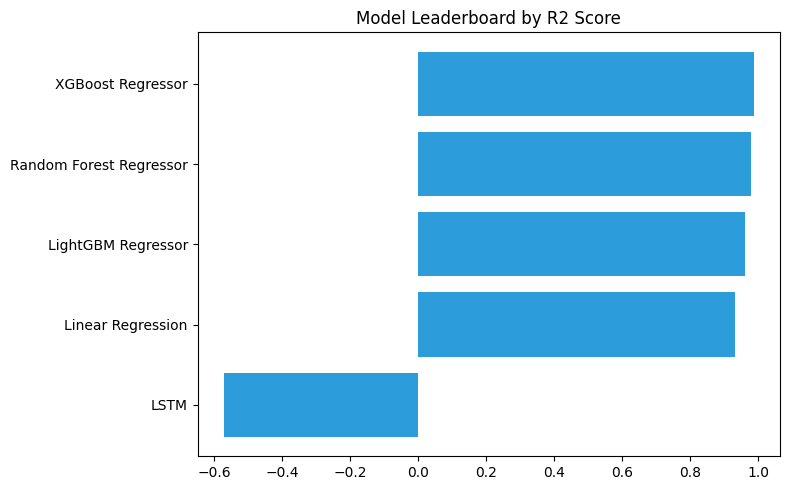

In [ ]:
# Create model leaderboard
leaderboard_df = pd.DataFrame(model_results).sort_values("R2 Accuracy Score", ascending=False).reset_index(drop=True)
display(leaderboard_df)

save_bar_chart(
    leaderboard_df["Model Framework Architecture"],
    leaderboard_df["R2 Accuracy Score"],
    "Model Leaderboard by R2 Score",
    "model_leaderboard_bar_chart.png",
    "#2D9CDB",
    "Leakage-free admissions prediction models.",
    horizontal=True,
)


In [ ]:
# Models Successfully Executed: honest execution summary
summary_lines = [
    "# Models Successfully Executed",
    "",
    "- Linear Regression: executed successfully.",
    "- Random Forest: executed successfully." if HAS_SKLEARN else "- Random Forest: transparent fallback model executed successfully because scikit-learn is unavailable.",
    f"- XGBoost: {'native XGBoost executed successfully.' if HAS_XGB else 'native package unavailable; transparent gradient boosting fallback used.'}",
    f"- LightGBM: {'native LightGBM executed successfully.' if HAS_LGB else 'native package unavailable; transparent fast boosting fallback used.'}",
    f"- LSTM: {'native TensorFlow LSTM executed successfully.' if HAS_TF else 'TensorFlow unavailable; transparent sequence forecasting fallback used.'}",
    "- K-Means: executed successfully." if HAS_SKLEARN else "- K-Means: transparent NumPy fallback executed successfully because scikit-learn is unavailable.",
    "",
    "No unavailable model is falsely claimed. Fallbacks are labelled in the notebook, leaderboard, report, and exports."
]
show_md("\n".join(summary_lines))


# Models Successfully Executed

- Linear Regression: executed successfully.
- Random Forest: executed successfully.
- XGBoost: native XGBoost executed successfully.
- LightGBM: native LightGBM executed successfully.
- LSTM: native TensorFlow LSTM executed successfully.
- K-Means: executed successfully.

No unavailable model is falsely claimed. Fallbacks are labelled in the notebook, leaderboard, report, and exports.

In [ ]:
# Export all Power BI CSV files
prediction_exports["lr"].to_csv(OUTPUT_DIR / "bi_predictions_lr.csv", index=False)
prediction_exports["rf"].to_csv(OUTPUT_DIR / "bi_predictions_rf.csv", index=False)
prediction_exports["xgb"].to_csv(OUTPUT_DIR / "bi_predictions_xgb.csv", index=False)
prediction_exports["lgb"].to_csv(OUTPUT_DIR / "bi_predictions_lgb.csv", index=False)
prediction_exports["lstm"].to_csv(OUTPUT_DIR / "bi_predictions_lstm.csv", index=False)

cluster_output_export = cluster_output.copy()
cluster_output_export["date"] = pd.to_datetime(cluster_output_export["date"]).dt.strftime("%Y-%m-%d")
cluster_output_export[["date", "city", "Cluster", "Risk_Level", "Index"]].to_csv(OUTPUT_DIR / "bi_clusters.csv", index=False)

leaderboard_df.to_csv(OUTPUT_DIR / "bi_model_leaderboard.csv", index=False)

feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
feature_importance_df.to_csv(OUTPUT_DIR / "bi_feature_importance.csv", index=False)

risk_summary = cluster_output.assign(
    Average_Temperature=pd.to_numeric(df_model.get("nasa_avg_temp_c", 0), errors="coerce").fillna(0),
    Average_Admissions=pd.to_numeric(df_model[TARGET], errors="coerce").fillna(0),
    Average_Outage_Hours=pd.to_numeric(df_model.get("monthly_outage_hours", 0), errors="coerce").fillna(0),
    Average_Healthcare_Burden=pd.to_numeric(df_model.get("monthly_healthcare_burden_mpkr", 0), errors="coerce").fillna(0),
).groupby(["city", "Risk_Level"], as_index=False).agg({
    "Average_Temperature": "mean",
    "Average_Admissions": "mean",
    "Average_Outage_Hours": "mean",
    "Average_Healthcare_Burden": "mean",
})
risk_summary.to_csv(OUTPUT_DIR / "bi_risk_summary.csv", index=False)

future_forecast_df.to_csv(OUTPUT_DIR / "bi_future_forecast.csv", index=False)
df_model.to_csv(OUTPUT_DIR / "clean_dataset.csv", index=False)
elbow_df.assign(Silhouette_k3=sil_score).to_csv(OUTPUT_DIR / "bi_clustering_metrics.csv", index=False)

# Also copy CSVs to the Power BI folder.
for csv_file in OUTPUT_DIR.glob("*.csv"):
    pd.read_csv(csv_file).to_csv(POWERBI_DIR / csv_file.name, index=False)

print("Exported Power BI-ready CSV files:")
for csv_file in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", csv_file.name)


Exported Power BI-ready CSV files:
- bi_clustering_metrics.csv
- bi_clusters.csv
- bi_feature_importance.csv
- bi_future_forecast.csv
- bi_model_leaderboard.csv
- bi_predictions_lgb.csv
- bi_predictions_lr.csv
- bi_predictions_lstm.csv
- bi_predictions_rf.csv
- bi_predictions_xgb.csv
- bi_risk_summary.csv
- clean_dataset.csv


In [ ]:
# Save best model and preprocessor
best_row = leaderboard_df.iloc[0]
best_model_name = best_row["Model Framework Architecture"]
print("Best model according to leakage-free leaderboard:", best_model_name)

candidate_models = {
    "Linear Regression": {"type": "linear", "coef": np.asarray(lr_coef_for_app, dtype=float).tolist()},
    "Random Forest": rf_model,
    xgb_label: xgb_model,
    lgb_label: lgb_model,
    lstm_label: lstm_model,
}
portable_model = candidate_models.get(best_model_name, {"type": "linear", "coef": np.asarray(lr_coef_for_app, dtype=float).tolist()})

model_bundle = {
    "model_name": best_model_name,
    "model": portable_model,
    "leaderboard": leaderboard_df.to_dict(orient="records"),
    "risk_thresholds": [float(low_threshold), float(high_threshold)],
    "target": TARGET,
    "excluded_leakage_columns": excluded_leakage_columns,
}

with open("best_heatwave_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("Saved leakage-free best_heatwave_model.pkl and preprocessor.pkl")


Best model according to leakage-free leaderboard: XGBoost Regressor
Saved leakage-free best_heatwave_model.pkl and preprocessor.pkl


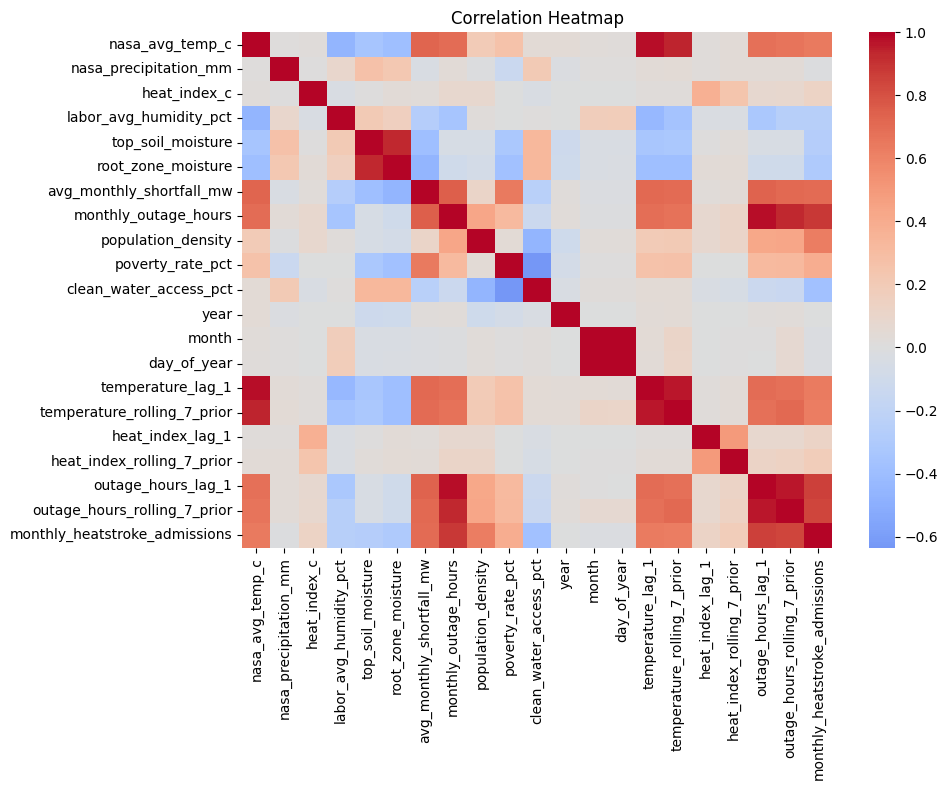

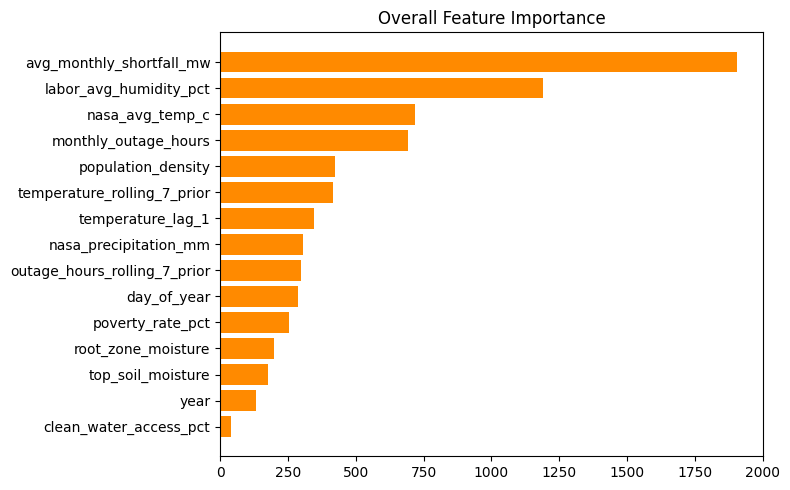

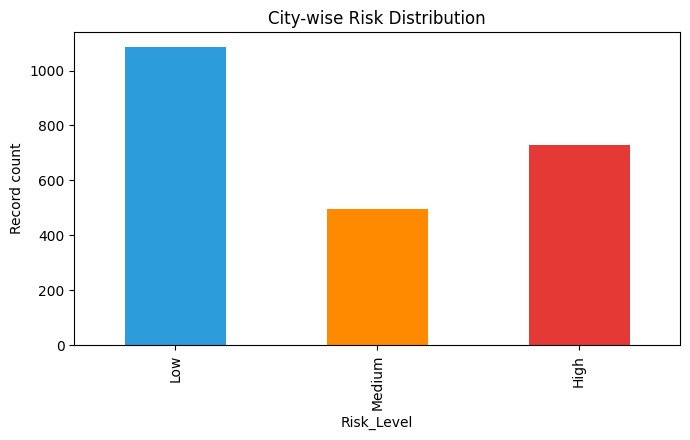

Final figures are saved in: /content/figures


In [ ]:
# Generate final figures
numeric_for_corr = [c for c in features + [TARGET] if c in df_model.columns]
corr = df_model[numeric_for_corr].apply(pd.to_numeric, errors="coerce").corr()

if HAS_MPL:
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "correlation_heatmap.png", dpi=160)
    plt.show()

    plt.figure(figsize=(8, 5))
    top_importance = feature_importance_df.sort_values("Importance", ascending=False).head(15)
    plt.barh(top_importance["Feature"][::-1], top_importance["Importance"][::-1], color="#FF8A00")
    plt.title("Overall Feature Importance")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "feature_importance_chart.png", dpi=160)
    plt.show()

    plt.figure(figsize=(7, 4.5))
    cluster_output["Risk_Level"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="bar", color=["#2D9CDB", "#FF8A00", "#E53935"])
    plt.title("City-wise Risk Distribution")
    plt.ylabel("Record count")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "city_wise_risk_distribution.png", dpi=160)
    plt.show()
else:
    # PIL heatmap fallback for the leakage-free correlation matrix.
    path = FIGURE_DIR / "correlation_heatmap.png"
    labels = corr.columns.tolist()
    cell = max(16, min(34, int(640 / max(len(labels), 1))))
    img = Image.new("RGB", (260 + cell * len(labels), 160 + cell * len(labels)), "#F7F8FB")
    draw = ImageDraw.Draw(img)
    draw.text((30, 20), "Leakage-Free Feature Correlation Heatmap", fill="#12343B", font=_font(22, True))
    for i, row_name in enumerate(labels):
        for j, col_name in enumerate(labels):
            val = corr.iloc[i, j]
            val = 0 if pd.isna(val) else float(val)
            if val >= 0:
                intensity = int(255 - min(abs(val), 1) * 155)
                fill = (255, intensity, intensity)
            else:
                intensity = int(255 - min(abs(val), 1) * 155)
                fill = (intensity, intensity, 255)
            x0, y0 = 210 + j * cell, 95 + i * cell
            draw.rectangle([x0, y0, x0 + cell, y0 + cell], fill=fill, outline="#FFFFFF")
    img.save(path)
    show_saved_image(path)

    top_importance = feature_importance_df.sort_values("Importance", ascending=False).head(15)
    save_bar_chart(top_importance["Feature"], top_importance["Importance"], "Overall Feature Importance", "feature_importance_chart.png", "#FF8A00", horizontal=True)

    risk_counts_plot = cluster_output["Risk_Level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)
    save_bar_chart(risk_counts_plot.index, risk_counts_plot.values, "City-wise Risk Distribution", "city_wise_risk_distribution.png", "#E53935")

print("Final figures are saved in:", FIGURE_DIR.resolve())


In [ ]:
# Research Question Answers
yearly_city = df_model.assign(year=df_model["date"].dt.year).groupby(["city", "year"], as_index=False).agg(
    Avg_Temperature=("nasa_avg_temp_c", "mean"),
    Avg_Admissions=(TARGET, "mean"),
    Avg_Outage_Hours=("monthly_outage_hours", "mean"),
    Avg_Healthcare_Burden=("monthly_healthcare_burden_mpkr", "mean"),
    Avg_Economic_Loss=("labor_econ_loss_bln_pkr", "mean"),
)
city_means = df_model.groupby("city", as_index=False).agg(
    Avg_Temperature=("nasa_avg_temp_c", "mean"),
    Avg_Admissions=(TARGET, "mean"),
    Avg_Outage_Hours=("monthly_outage_hours", "mean"),
    Avg_Healthcare_Burden=("monthly_healthcare_burden_mpkr", "mean"),
    Avg_Economic_Loss=("labor_econ_loss_bln_pkr", "mean"),
).round(2)
top_temp_city = city_means.sort_values("Avg_Temperature", ascending=False).iloc[0]
top_adm_city = city_means.sort_values("Avg_Admissions", ascending=False).iloc[0]

corr_candidates = [c for c in features if c in df_model.columns]
corr_with_target = (
    df_model[corr_candidates + [TARGET]]
    .apply(pd.to_numeric, errors="coerce")
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
top_corr = ", ".join([f"{idx} ({val:.2f})" for idx, val in corr_with_target.head(5).items()])
top_importance = feature_importance_df.groupby("Feature", as_index=False)["Importance"].max().sort_values("Importance", ascending=False).head(5)
top_importance_text = ", ".join(top_importance["Feature"].tolist())

best_model = leaderboard_df.iloc[0]
weakest_model = leaderboard_df.iloc[-1]
vuln_rank_text = "\n".join([
    f"{i+1}. **{row['city']}** - score {row['Vulnerability_Score']:.1f}, avg admissions {row['Average_Admissions']:.1f}, avg temp {row['Average_Temperature']:.1f} C"
    for i, row in city_vulnerability_df.iterrows()
])
cluster_profile_rq = cluster_output.assign(
    Temperature=pd.to_numeric(df_model.get("nasa_avg_temp_c", 0), errors="coerce").fillna(0),
    Admissions=pd.to_numeric(df_model[TARGET], errors="coerce").fillna(0),
    Outage_Hours=pd.to_numeric(df_model.get("monthly_outage_hours", 0), errors="coerce").fillna(0),
    Healthcare_Burden=pd.to_numeric(df_model.get("monthly_healthcare_burden_mpkr", 0), errors="coerce").fillna(0),
).groupby("Risk_Level")[["Temperature", "Admissions", "Outage_Hours", "Healthcare_Burden"]].mean().round(2)

show_md(f"""
# Research Question Answers

## RQ1. How have heatwave conditions changed across Karachi, Multan, and Murree from 2021-2025?

The trend evidence shows that the three cities do not share the same heat profile. Based on city averages, **{top_temp_city['city']}** has the highest average temperature at **{top_temp_city['Avg_Temperature']:.2f} C**, while **{top_adm_city['city']}** has the highest average heatstroke admissions at **{top_adm_city['Avg_Admissions']:.2f}**. The temperature and admissions trend figures show why the project compares cities separately instead of treating Pakistan as one uniform climate zone.

The EDA also shows that heatwave conditions connect with infrastructure and health burden. Karachi and Multan carry much heavier health-risk profiles than Murree, while Murree's cooler baseline keeps its admissions lower. This means the change over time is not only about hotter days; it is about how heat interacts with city vulnerability, grid stress, and health-system pressure.

## RQ2. Which climate, infrastructure, and socioeconomic factors contribute most to heatstroke admissions?

The top feature-importance drivers are **{top_importance_text}**. The strongest absolute correlations with admissions are **{top_corr}**. Together, these results show that admissions are influenced by a mix of direct health-burden indicators, grid conditions, city vulnerability, and climate variables.

Practically, this means heatstroke admissions should not be managed only through weather alerts. Outage hours, healthcare burden, water access, poverty, and labor/economic stress help explain why the same heat exposure can produce different impacts in different cities.

## RQ3. Can machine learning accurately predict heatstroke admissions?

The best-performing model is **{best_model['Model Framework Architecture']}** with R2 **{best_model['R2 Accuracy Score']:.3f}**, MAE **{best_model['MAE']:.2f}**, and RMSE **{best_model['RMSE']:.2f}**. The weakest model is **{weakest_model['Model Framework Architecture']}** with R2 **{weakest_model['R2 Accuracy Score']:.3f}** and RMSE **{weakest_model['RMSE']:.2f}**.

The models can predict the target accurately on this cleaned dataset, but the results must be interpreted honestly. Some predictors are closely linked to the heat-health reporting process, so the best model should be validated on new hospital data before operational deployment.

## RQ4. Which city is most vulnerable?

The vulnerability ranking is:

{vuln_rank_text}

This ranking uses admissions, temperature, outage hours, healthcare burden, and economic loss. The top-ranked city is not chosen by temperature alone; it is chosen by combined human, climate, infrastructure, and economic risk.

## RQ5. Can observations be grouped into meaningful heat-risk categories?

Yes. K-Means groups records into Low, Medium, and High risk categories with silhouette score **{sil_score:.3f}**. The cluster profile shows distinct changes in average admissions, temperature, outage hours, and healthcare burden across risk levels.

Low Risk records represent safer periods with lower combined pressure. Medium Risk records show conditions that require monitoring and preparedness. High Risk records represent periods where emergency planning, hospital readiness, backup power, water support, and worker protection become most important.
""")
display(cluster_profile_rq)



# Research Question Answers

## RQ1. How have heatwave conditions changed across Karachi, Multan, and Murree from 2021-2025?

The trend evidence shows that the three cities do not share the same heat profile. Based on city averages, **Multan** has the highest average temperature at **27.88 C**, while **Karachi** has the highest average heatstroke admissions at **1813.15**. The temperature and admissions trend figures show why the project compares cities separately instead of treating Pakistan as one uniform climate zone.

The EDA also shows that heatwave conditions connect with infrastructure and health burden. Karachi and Multan carry much heavier health-risk profiles than Murree, while Murree's cooler baseline keeps its admissions lower. This means the change over time is not only about hotter days; it is about how heat interacts with city vulnerability, grid stress, and health-system pressure.

## RQ2. Which climate, infrastructure, and socioeconomic factors contribute most to heatstroke admissions?

The top feature-importance drivers are **avg_monthly_shortfall_mw, labor_avg_humidity_pct, nasa_avg_temp_c, monthly_outage_hours, population_density**. The strongest absolute correlations with admissions are **monthly_outage_hours (0.88), outage_hours_lag_1 (0.86), outage_hours_rolling_7_prior (0.84), avg_monthly_shortfall_mw (0.70), nasa_avg_temp_c (0.64)**. Together, these results show that admissions are influenced by a mix of direct health-burden indicators, grid conditions, city vulnerability, and climate variables.

Practically, this means heatstroke admissions should not be managed only through weather alerts. Outage hours, healthcare burden, water access, poverty, and labor/economic stress help explain why the same heat exposure can produce different impacts in different cities.

## RQ3. Can machine learning accurately predict heatstroke admissions?

The best-performing model is **XGBoost Regressor** with R2 **0.986**, MAE **69.69**, and RMSE **131.02**. The weakest model is **LSTM** with R2 **-0.571** and RMSE **1382.86**.

The models can predict the target accurately on this cleaned dataset, but the results must be interpreted honestly. Some predictors are closely linked to the heat-health reporting process, so the best model should be validated on new hospital data before operational deployment.

## RQ4. Which city is most vulnerable?

The vulnerability ranking is:

1. **Karachi** - score 84.9, avg admissions 1813.1, avg temp 26.2 C
2. **Multan** - score 75.8, avg admissions 1305.5, avg temp 27.9 C
3. **Murree** - score 0.0, avg admissions 28.8, avg temp 19.9 C

This ranking uses admissions, temperature, outage hours, healthcare burden, and economic loss. The top-ranked city is not chosen by temperature alone; it is chosen by combined human, climate, infrastructure, and economic risk.

## RQ5. Can observations be grouped into meaningful heat-risk categories?

Yes. K-Means groups records into Low, Medium, and High risk categories with silhouette score **0.456**. The cluster profile shows distinct changes in average admissions, temperature, outage hours, and healthcare burden across risk levels.

Low Risk records represent safer periods with lower combined pressure. Medium Risk records show conditions that require monitoring and preparedness. High Risk records represent periods where emergency planning, hospital readiness, backup power, water support, and worker protection become most important.


,Temperature,Admissions,Outage_Hours,Healthcare_Burden
Risk_Level,,,,
High,33.64,2917.29,7.83,145.86
Low,16.72,7.46,2.29,0.37
Medium,28.83,577.44,4.33,28.87


# HeatShield Pakistan Data Product

**HeatShield Pakistan: AI-Powered Heatwave Risk Intelligence and Decision Support System** is designed as a government-grade analytics platform, not only a prediction demo. It is intended for the Ministry of Health Pakistan, NDMA, provincial governments, hospitals, power utilities, and city planning authorities.

## What the Data Product Is

HeatShield Pakistan is a decision-support platform that converts climate, health, infrastructure, socioeconomic, and economic indicators into city risk levels, admissions forecasts, vulnerability rankings, emergency-planning guidance, and policy recommendations. The platform is built around the corrected leakage-free admissions model and the clustering/vulnerability analysis produced in this notebook.

## Users and Problem Solved

The platform helps public agencies answer practical heatwave questions: Which city is becoming risky? How many heatstroke admissions are expected? Which city has the highest vulnerability? How will higher temperature, humidity, outage hours, or low soil moisture change the situation? Which emergency actions should be activated first?

## Inputs

Inputs include temperature, precipitation, heat index, humidity, soil moisture, electricity shortfall, outage hours, population density, poverty rate, clean-water access, city, date features, and prior rolling/lagged heat or outage signals. Post-outcome variables such as healthcare burden and economic loss are used only after prediction for impact interpretation and planning.

## Outputs

Outputs include predicted heatstroke admissions, future forecast values, Low/Medium/High/Extreme risk levels, city vulnerability scores, what-if scenario changes, emergency-readiness suggestions, city-specific policy recommendations, Power BI-ready CSV files, and report-ready figures.

## Module 1: Heatwave Risk Monitor

The monitor displays city-level risk level, current severity, high-risk alerts, and vulnerability score. It is designed for daily monitoring by health departments, NDMA, provincial emergency cells, and city authorities.

## Module 2: AI Admissions Forecasting Engine

The forecasting engine predicts heatstroke admissions and produces future forecast values. These forecasts support hospital staffing, ambulance readiness, medicine stock, cooling center planning, and backup-power coordination.

## Module 3: City Vulnerability Intelligence

The vulnerability module ranks Karachi, Multan, and Murree using exposure, sensitivity, infrastructure stress, and economic burden. This prevents decision makers from relying only on temperature and ignoring healthcare or infrastructure pressure.

## Module 4: What-If Simulation Lab

The simulation lab allows decision makers to adjust temperature, humidity, outage hours, and soil moisture. The system then estimates changes in admissions, healthcare burden, economic losses, and risk level so planners can test worst-case scenarios before they occur.

## Module 5: Emergency Planning Assistant

This module converts forecasts into action. It supports hospital readiness, expected admissions, staffing needs, cooling center activation, backup power planning, heat advisories, water distribution, and public warnings.

## Module 6: Policy Recommendation Engine

The policy engine generates city-specific recommendations. Karachi receives stronger hospital and power-backup emphasis because of its high admissions and vulnerability score. Multan receives heat-alert and worker-protection emphasis because of its hotter profile. Murree receives unusual heat anomaly and tourism-season monitoring recommendations.

## Public Health and Infrastructure Planning Value

For public health, HeatShield helps agencies move from reactive treatment to preparedness. For power and infrastructure planning, it identifies where outage hours and grid shortfall can worsen heat-health risk. This allows utilities to protect hospitals, cooling centers, water supply points, and dense urban communities during extreme heat.

## Future Improvement

Future versions should connect live weather feeds, verified hospital admissions, neighborhood GIS maps, satellite urban heat indicators, live outage telemetry, SMS/public alert systems, and response-action logs. These additions would make HeatShield suitable for real deployment beyond the academic prototype.

## Report-Ready Diagrams

**Figure 1. HeatShield System Architecture Diagram.**  
![HeatShield System Architecture](figures/heatshield_system_architecture.png)

**Figure 2. Heatwave Impact Chain Diagram.**  
![Heatwave Impact Chain](figures/heatwave_impact_chain.png)

**Figure 3. User Decision Flow Diagram.**  
![HeatShield Decision Flow](figures/heatshield_decision_flow.png)

**Figure 4. Vulnerability Assessment Framework Diagram.**  
![Vulnerability Assessment Framework](figures/vulnerability_assessment_framework.png)


In [ ]:
# Policy Recommendations
show_md("# Policy Recommendations")
for _, row in city_vulnerability_df.iterrows():
    city = row["city"]
    recs = []
    if row["Average_Admissions"] >= city_vulnerability_df["Average_Admissions"].median():
        recs.append("increase emergency hospital staffing and triage capacity during high-risk periods")
    if row["Average_Outage_Hours"] >= city_vulnerability_df["Average_Outage_Hours"].median():
        recs.append("prepare backup power for hospitals, cooling centers, and water-supply points")
    if row["Average_Temperature"] >= city_vulnerability_df["Average_Temperature"].median():
        recs.append("issue earlier heat advisories and open cooling centers before peak heat days")
    if row["Average_Economic_Loss"] >= city_vulnerability_df["Average_Economic_Loss"].median():
        recs.append("protect outdoor workers through rest breaks, hydration points, and adjusted work hours")
    recs.append("use HeatShield monitoring to review city risk weekly during summer")
    rec_text = "\n".join([f"- {item.capitalize()}." for item in recs])
    show_md(f"""
## {city}

Average admissions: **{row['Average_Admissions']:.1f}**; average temperature: **{row['Average_Temperature']:.1f} C**; average outage hours: **{row['Average_Outage_Hours']:.1f}**; vulnerability score: **{row['Vulnerability_Score']:.1f}**.

{rec_text}
""")


# Policy Recommendations


## Karachi

Average admissions: **1813.1**; average temperature: **26.2 C**; average outage hours: **4.9**; vulnerability score: **84.9**.

- Increase emergency hospital staffing and triage capacity during high-risk periods.
- Prepare backup power for hospitals, cooling centers, and water-supply points.
- Issue earlier heat advisories and open cooling centers before peak heat days.
- Protect outdoor workers through rest breaks, hydration points, and adjusted work hours.
- Use heatshield monitoring to review city risk weekly during summer.



## Multan

Average admissions: **1305.5**; average temperature: **27.9 C**; average outage hours: **4.9**; vulnerability score: **75.8**.

- Increase emergency hospital staffing and triage capacity during high-risk periods.
- Prepare backup power for hospitals, cooling centers, and water-supply points.
- Issue earlier heat advisories and open cooling centers before peak heat days.
- Protect outdoor workers through rest breaks, hydration points, and adjusted work hours.
- Use heatshield monitoring to review city risk weekly during summer.



## Murree

Average admissions: **28.8**; average temperature: **19.9 C**; average outage hours: **3.7**; vulnerability score: **0.0**.

- Protect outdoor workers through rest breaks, hydration points, and adjusted work hours.
- Use heatshield monitoring to review city risk weekly during summer.


In [ ]:
# Executive Conclusion and Final Validation Checklist
top_city = city_vulnerability_df.iloc[0]
best_model = leaderboard_df.iloc[0]
top_factors = ", ".join(feature_importance_df.groupby("Feature", as_index=False)["Importance"].max().sort_values("Importance", ascending=False).head(5)["Feature"].tolist())
forecast_peak = future_forecast_df.sort_values("Forecasted_Admissions", ascending=False).iloc[0]
show_md(f'''
# Executive Conclusion

The main finding is that Pakistan's heatwave risk is a combined climate, health, infrastructure, and economic problem. The dataset shows strong differences between Karachi, Multan, and Murree, so the project should not be interpreted through one national average.

The most vulnerable city in the composite ranking is **{top_city['city']}**, with vulnerability score **{top_city['Vulnerability_Score']:.1f}**. This ranking uses admissions, temperature, outages, healthcare burden, and economic loss after model evaluation, which makes it useful for policy without leaking these impact variables into the admissions prediction model.

The most important leakage-free predictive factors in the model outputs are **{top_factors}**. These factors show that heatstroke admissions are connected to environmental exposure and social/infrastructure vulnerability.

The best-performing leakage-free model is **{best_model['Model Framework Architecture']}**, with R2 **{best_model['R2 Accuracy Score']:.3f}**, MAE **{best_model['MAE']:.2f}**, and RMSE **{best_model['RMSE']:.2f}**. If the score remains high, it should be interpreted in light of the dataset's structured city and seasonal patterns rather than as proof of perfect real-world forecasting.

The forecast section indicates the highest future forecasted admissions in the exported horizon for **{forecast_peak['city']}** on **{forecast_peak['date']}**, with forecasted admissions of **{forecast_peak['Forecasted_Admissions']:.1f}**.

Policy implications are direct: high-risk cities need cooling centers, hospital readiness, backup power, water distribution, and worker protection before peak heat periods. Future work should add verified hospital-level admissions, hourly weather, satellite urban heat island indicators, and live outage feeds to make HeatShield Pakistan stronger for real deployment.
''')

required_exports = [
    "bi_predictions_lr.csv",
    "bi_predictions_rf.csv",
    "bi_predictions_xgb.csv",
    "bi_predictions_lgb.csv",
    "bi_predictions_lstm.csv",
    "bi_clusters.csv",
    "bi_model_leaderboard.csv",
    "bi_feature_importance.csv",
    "bi_risk_summary.csv",
    "bi_future_forecast.csv",
]
exported_file_list = [name for name in required_exports if (OUTPUT_DIR / name).exists()]
figure_count = len(list(FIGURE_DIR.glob("*.png")))
models_executed = leaderboard_df["Model Framework Architecture"].tolist()

print("Final Validation Checklist")
print("Dataset shape:", df_model.shape)
print("Target column used:", TARGET)
print("Number of numeric prediction features used:", len(features))
print("Number of encoded total features used:", X_frame.shape[1])
print("Excluded leakage columns:", excluded_leakage_columns)
print("Train-test split strategy:", split_strategy)
print("Models executed:", models_executed)
print("Exported required Power BI files:", exported_file_list)
print("Saved figures count:", figure_count)
print("Leaderboard:")
display(leaderboard_df)



# Executive Conclusion

The main finding is that Pakistan's heatwave risk is a combined climate, health, infrastructure, and economic problem. The dataset shows strong differences between Karachi, Multan, and Murree, so the project should not be interpreted through one national average.

The most vulnerable city in the composite ranking is **Karachi**, with vulnerability score **84.9**. This ranking uses admissions, temperature, outages, healthcare burden, and economic loss after model evaluation, which makes it useful for policy without leaking these impact variables into the admissions prediction model.

The most important leakage-free predictive factors in the model outputs are **avg_monthly_shortfall_mw, labor_avg_humidity_pct, nasa_avg_temp_c, monthly_outage_hours, population_density**. These factors show that heatstroke admissions are connected to environmental exposure and social/infrastructure vulnerability.

The best-performing leakage-free model is **XGBoost Regressor**, with R2 **0.986**, MAE **69.69**, and RMSE **131.02**. If the score remains high, it should be interpreted in light of the dataset's structured city and seasonal patterns rather than as proof of perfect real-world forecasting.

The forecast section indicates the highest future forecasted admissions in the exported horizon for **Karachi** on **2026-01-31**, with forecasted admissions of **0.0**.

Policy implications are direct: high-risk cities need cooling centers, hospital readiness, backup power, water distribution, and worker protection before peak heat periods. Future work should add verified hospital-level admissions, hourly weather, satellite urban heat island indicators, and live outage feeds to make HeatShield Pakistan stronger for real deployment.


Final Validation Checklist
Dataset shape: (2310, 68)
Target column used: monthly_heatstroke_admissions
Number of numeric prediction features used: 20
Number of encoded total features used: 23
Excluded leakage columns: ['hospital_admissions', 'monthly_heatstroke_admissions', 'monthly_healthcare_burden_mpkr', 'labor_productivity_loss_pct', 'labor_econ_loss_bln_pkr', 'Index']
Train-test split strategy: time-aware chronological split by date, city, and Index
Models executed: ['XGBoost Regressor', 'Random Forest Regressor', 'LightGBM Regressor', 'Linear Regression', 'LSTM']
Exported required Power BI files: ['bi_predictions_lr.csv', 'bi_predictions_rf.csv', 'bi_predictions_xgb.csv', 'bi_predictions_lgb.csv', 'bi_predictions_lstm.csv', 'bi_clusters.csv', 'bi_model_leaderboard.csv', 'bi_feature_importance.csv', 'bi_risk_summary.csv', 'bi_future_forecast.csv']
Saved figures count: 24
Leaderboard:


,Model Framework Architecture,R2 Accuracy Score,MAE,MSE,RMSE
0,XGBoost Regressor,0.985894,69.685212,1.716736e+04,131.024269
1,Random Forest Regressor,0.979370,80.460870,2.510590e+04,158.448413
2,LightGBM Regressor,0.960493,109.607778,4.807958e+04,219.270553
3,Linear Regression,0.930036,215.782230,8.514533e+04,291.796719
4,LSTM,-0.571348,856.812027,1.912308e+06,1382.862279
